# Active Preference Learning via Polytope Volume Removal

Instead of heuristic sample filtering, we maintain the feasible set $\Omega_t$ as an **explicit polytope** $\{\omega : A\omega \leq b\}$.

Each pairwise response (left, right, indifferent, incomparable) adds **linear constraints** on $\omega$,
and we select queries to **maximize expected volume removal** (Sadigh et al. 2017).

### Constraint rules (from the frame model)

Given query gaps $\Delta_j$ and thresholds $\tau, \tau'$:

| Response | Constraints on $\omega$ |
|----------|------------------------|
| **Left** ($Y \succ Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) \geq 0$ |
| **Right** ($Y \prec Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$ and $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) \leq 0$ |
| **Indifferent** ($Y \sim Y'$) | $\sum \omega_j |\Delta_j| \leq \tau - \eta$ |
| **Incomparable** ($Y \bowtie Y'$) | $\sum \omega_j |\Delta_j| \geq \tau$, $\sum \omega_j (\Delta_j - \tau' |\Delta_j|) < 0$, $\sum \omega_j (\Delta_j + \tau' |\Delta_j|) > 0$ |

In [37]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.spatial.distance import pdist
from typing import List, Tuple, Optional, Set, Callable
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# ============================================================================
# Configuration
# ============================================================================

FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']

FEATURE_RANGES = {
    'elderlyDep': (0, 5),
    'lifeYearsGained': (0, 25),
    'obesity': (0, 5),
    'weeklyWorkhours': (0, 50),
    'yearsWaiting': (1, 10)
}

# Algorithm parameters (can be changed at test time)
TAU = 0.1           # Intensity threshold
TAU_PRIME = 0.1     # Resolvability threshold
LAMBDA_X = 1.0      # Query scaling factor

print(f'Features: {FEATURE_NAMES}')
print(f'tau={TAU}, tau_prime={TAU_PRIME}, lambda_x={LAMBDA_X}')


# ============================================================================
# Data structures
# ============================================================================

@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: float
    lifeYearsGained: float
    obesity: float
    weeklyWorkhours: float
    yearsWaiting: float

    def to_array(self) -> np.ndarray:
        """Convert to numpy array in standard feature order."""
        return np.array([
            self.elderlyDep,
            self.lifeYearsGained,
            self.obesity,
            self.weeklyWorkhours,
            self.yearsWaiting
        ], dtype=float)

    @classmethod
    def from_array(cls, arr: np.ndarray) -> 'Patient':
        """Create Patient from numpy array."""
        return cls(
            elderlyDep=float(arr[0]),
            lifeYearsGained=float(arr[1]),
            obesity=float(arr[2]),
            weeklyWorkhours=float(arr[3]),
            yearsWaiting=float(arr[4])
        )

    def __repr__(self):
        return f"Patient(elder={self.elderlyDep}, life={self.lifeYearsGained}, " \
               f"obesity={self.obesity}, work={self.weeklyWorkhours}, wait={self.yearsWaiting})"


@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

    def __repr__(self):
        return f"Query:\n  LEFT:  {self.patient_left}\n  RIGHT: {self.patient_right}"


# ============================================================================
# Query generation
# ============================================================================

def generate_random_patient() -> Patient:
    """Generate a random patient with features in valid ranges."""
    return Patient(
        elderlyDep=np.random.randint(0, 5),
        lifeYearsGained=np.random.randint(0, 25),
        obesity=np.random.randint(0, 5),
        weeklyWorkhours=np.random.randint(0, 50),
        yearsWaiting=np.random.randint(1, 10)
    )


def generate_random_patient_normalized() -> Patient:
    """Generate a random patient with features normalized to [0, 1]."""
    return Patient(
        elderlyDep=np.random.uniform(0, 1),
        lifeYearsGained=np.random.uniform(0, 1),
        obesity=np.random.uniform(0, 1),
        weeklyWorkhours=np.random.uniform(0, 1),
        yearsWaiting=np.random.uniform(0, 1)
    )


def generate_candidate_queries_normalized(n_candidates: int = 50) -> List[PairwiseQuery]:
    """Generate candidate queries with features normalized to [0,1]."""
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized()
        right = generate_random_patient_normalized()
        candidates.append(PairwiseQuery(left, right))
    return candidates


print("Data structures defined: Patient, PairwiseQuery")
print("Query generators: generate_random_patient, generate_random_patient_normalized, generate_candidate_queries_normalized")


Features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
tau=0.1, tau_prime=0.1, lambda_x=1.0
Data structures defined: Patient, PairwiseQuery
Query generators: generate_random_patient, generate_random_patient_normalized, generate_candidate_queries_normalized


In [38]:
# ============================================================================
# Core Frame Model Computations
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active (decisive) frames.

    Parameters
    ----------
    query : PairwiseQuery
        The comparison query
    lambda_x : float
        Scaling factor for feature differences
    V : np.ndarray, optional
        Sign matrix (diagonal) to handle negative weights. 
        V[i,i] = -1 if oracle weight i is negative, else +1.
    tau : float
        Threshold for determining active frames

    Returns
    -------
    gaps : np.ndarray, shape (n_frames,)
        Gap for each frame: lambda_x * V @ (left_j - right_j)
    active_frames : Set[int]
        Frames where |gap_j| > tau (frames that "speak" to this query)
    """
    left_features = query.patient_left.to_array()
    right_features = query.patient_right.to_array()
    feature_diff = left_features - right_features
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score delta(omega) and intensity r(omega).

    Parameters
    ----------
    gaps : np.ndarray
        Per-frame gaps from compute_frame_gaps
    weights : np.ndarray
        Weight vector omega (on simplex)
    active_frames : Set[int]
        Which frames are active for this query

    Returns
    -------
    delta_omega : float
        Weighted sum of gaps: sum_j omega_j * gap_j
        Positive = left is better, Negative = right is better
    r_omega : float
        Weighted sum of absolute gaps: sum_j omega_j * |gap_j|
        Measures "intensity" - how strongly the frames speak
    """
    if len(active_frames) == 0:
        return 0.0, 0.0

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    active_weights = weights[active_list]

    delta_omega = np.dot(active_weights, active_gaps)
    r_omega = np.dot(active_weights, np.abs(active_gaps))

    return delta_omega, r_omega


def predict_response(
    query: PairwiseQuery,
    weights: np.ndarray,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None
) -> str:
    """
    Predict response for a query given a weight vector (DETERMINISTIC).

    Parameters
    ----------
    query : PairwiseQuery
        The comparison query
    weights : np.ndarray
        Weight vector omega (on simplex, all non-negative)
    tau : float
        Intensity threshold
    lambda_x : float
        Scaling factor
    tau_prime : float
        Resolvability threshold
    V : np.ndarray, optional
        Sign matrix (diagonal) to handle negative oracle weights.

    Decision rule:
    - r < tau           -> 'indifferent'  (not enough intensity)
    - |delta| < tau'*r  -> 'incomparable' (frames disagree)
    - delta >= tau'*r   -> 'left'         (left is better)
    - delta <= -tau'*r  -> 'right'        (right is better)

    Returns one of: 'left', 'right', 'indifferent', 'incomparable'
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x=lambda_x, V=V, tau=tau)
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)

    if r_omega < tau:
        return 'indifferent'
    if r_omega >= tau and np.abs(delta_omega) < tau_prime * r_omega:
        return 'incomparable'
    elif r_omega >= tau and delta_omega >= tau_prime * r_omega:
        return 'left'
    elif r_omega >= tau and delta_omega <= -tau_prime * r_omega:
        return 'right'
    else:
        return 'indifferent'


def make_sign_matrix(beta: np.ndarray) -> np.ndarray:
    """
    Create diagonal sign matrix V from weight vector beta.
    
    V[i,i] = -1 if beta[i] < 0, else +1
    
    This allows the polytope algorithm (which requires non-negative weights)
    to handle negative oracle weights by absorbing signs into V.
    
    To recover signed weights: beta = V @ omega (where omega >= 0)
    """
    return np.diag(np.sign(beta))


print("Core functions defined:")
print("  - compute_frame_gaps(query, lambda_x, V, tau) -> (gaps, active_frames)")
print("  - compute_aggregate_scores(gaps, weights, active_frames) -> (delta_omega, r_omega)")
print("  - predict_response(query, weights, tau, lambda_x, tau_prime, V) -> response")
print("  - make_sign_matrix(beta) -> V (diagonal sign matrix)")

Core functions defined:
  - compute_frame_gaps(query, lambda_x, V, tau) -> (gaps, active_frames)
  - compute_aggregate_scores(gaps, weights, active_frames) -> (delta_omega, r_omega)
  - predict_response(query, weights, tau, lambda_x, tau_prime, V) -> response
  - make_sign_matrix(beta) -> V (diagonal sign matrix)


In [39]:
# ============================================================================
# Noise Injection for Latent Margins (Δ, r) - Unified Noise Model
# ============================================================================
#
# We add noise to latent margins:
#   Δ̃ = Δ + ε_Δ   (additive noise on preference score)
#   r̃ = r * exp(ε_r)  (multiplicative noise on intensity, keeps r̃ > 0)
#
# When scale_r = 0, only Δ gets noise (BT-equivalent model).
# When scale_r > 0, both Δ and r get noise (2D model).
#
# The decision rule uses (Δ̃, r̃):
#   - indifferent if r̃ < τ
#   - incomparable if r̃ ≥ τ and |Δ̃| < τ'r̃
#   - left if r̃ ≥ τ and Δ̃ ≥ τ'r̃
#   - right if r̃ ≥ τ and Δ̃ ≤ -τ'r̃
# ============================================================================

from typing import Callable, Tuple


def no_noise(delta_omega: float, r_omega: float) -> Tuple[float, float]:
    """No noise - deterministic model."""
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0
) -> Callable:
    """
    Create a noise function for the latent margin model.
    
    Args:
        noise_type: 'logistic' or 'normal'
        scale_delta: Scale for Δ noise (additive)
        scale_r: Scale for r noise (multiplicative via exp). 0 = no r noise.
    
    Returns:
        noise_fn(delta, r) -> (delta_tilde, r_tilde)
    
    When scale_r = 0, this is equivalent to the BT model (delta-only noise).
    When scale_r > 0, r gets multiplicative noise: r̃ = r * exp(ε_r), keeping r̃ > 0.
    """
    def noise_fn(delta_omega: float, r_omega: float) -> Tuple[float, float]:
        # Delta noise (always applied, additive)
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(loc=0, scale=scale_delta)
        else:  # normal
            eps_delta = np.random.normal(loc=0, scale=scale_delta)
        
        delta_tilde = delta_omega + eps_delta
        
        # r noise (multiplicative to keep r > 0)
        if scale_r > 0:
            if noise_type == 'logistic':
                eps_r = np.random.logistic(loc=0, scale=scale_r)
            else:
                eps_r = np.random.normal(loc=0, scale=scale_r)
            r_tilde = r_omega * np.exp(eps_r)
        else:
            r_tilde = r_omega
        
        return delta_tilde, r_tilde
    
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable = no_noise,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Predict response with noise injection into latent margins (Δ, r).
    
    This function:
    1. Computes deterministic (Δ, r)
    2. Applies noise_fn to get (Δ̃, r̃)
    3. Applies decision rule using (Δ̃, r̃, τ, τ')
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    
    # Inject noise
    delta_tilde, r_tilde = noise_fn(delta, r)
    
    # Decision rule with noisy values
    if r_tilde < tau:
        return 'indifferent'
    if np.abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    elif delta_tilde >= tau_prime * r_tilde:
        return 'left'
    else:
        return 'right'


print("Noise model unified:")
print("  - create_noise_fn(noise_type, scale_delta, scale_r): creates noise function")
print("    - scale_r=0: delta-only noise (BT-equivalent)")
print("    - scale_r>0: 2D noise model (multiplicative on r)")
print("  - predict_response_noisy: applies noise and returns response")


Noise model unified:
  - create_noise_fn(noise_type, scale_delta, scale_r): creates noise function
    - scale_r=0: delta-only noise (BT-equivalent)
    - scale_r>0: 2D noise model (multiplicative on r)
  - predict_response_noisy: applies noise and returns response


In [40]:
# ============================================================================
# Test: Verify BT Equivalence
# ============================================================================
# When tau=tau'=0 with logistic noise, predict_response_noisy should give
# the same probability distribution as Bradley-Terry.

from collections import Counter
from scipy.special import expit  # sigmoid function

np.random.seed(42)

# Create a simple test query
left = Patient(elderlyDep=0.8, lifeYearsGained=0.6, obesity=0.3, weeklyWorkhours=0.5, yearsWaiting=0.4)
right = Patient(elderlyDep=0.2, lifeYearsGained=0.4, obesity=0.7, weeklyWorkhours=0.5, yearsWaiting=0.6)
query = PairwiseQuery(left, right)

# Weight vector
weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# Compute delta_omega (what BT uses)
delta_x = left.to_array() - right.to_array()
delta_omega = np.dot(weights, delta_x)

print("Test Setup:")
print(f"  delta_x (left - right): {delta_x}")
print(f"  weights: {weights}")
print(f"  delta_omega = w . delta_x = {delta_omega:.4f}")
print()

# BT theoretical probability
bt_prob_left = expit(delta_omega)  # sigmoid(delta_omega)
print(f"Bradley-Terry P(left) = sigmoid({delta_omega:.4f}) = {bt_prob_left:.4f}")
print()

# Empirical test: run many trials with tau=tau'=0 and logistic noise
n_trials = 10000
responses = []
for _ in range(n_trials):
    r = predict_response_noisy(
        query, weights, 
        noise_fn=create_noise_fn('logistic', scale_delta=1.0),
        tau=0.0, tau_prime=0.0, lambda_x=1.0, V=None
    )
    responses.append(r)

counts = Counter(responses)
empirical_prob_left = counts['left'] / n_trials

print(f"Empirical test ({n_trials} trials, tau=tau'=0, logistic noise):")
print(f"  Response counts: {dict(counts)}")
print(f"  Empirical P(left) = {empirical_prob_left:.4f}")
print()
print(f"Match: BT={bt_prob_left:.4f} vs Empirical={empirical_prob_left:.4f}")
print(f"  Difference: {abs(bt_prob_left - empirical_prob_left):.4f}")
if abs(bt_prob_left - empirical_prob_left) < 0.02:
    print("  ✓ Close match! Frame model with logistic noise ≈ Bradley-Terry")
else:
    print("  ✗ Mismatch - something is wrong")


Test Setup:
  delta_x (left - right): [ 0.6  0.2 -0.4  0.  -0.2]
  weights: [0.1 0.5 0.1 0.1 0.2]
  delta_omega = w . delta_x = 0.0800

Bradley-Terry P(left) = sigmoid(0.0800) = 0.5200

Empirical test (10000 trials, tau=tau'=0, logistic noise):
  Response counts: {'right': 4864, 'left': 5136}
  Empirical P(left) = 0.5136

Match: BT=0.5200 vs Empirical=0.5136
  Difference: 0.0064
  ✓ Close match! Frame model with logistic noise ≈ Bradley-Terry


In [41]:
# ============================================================================
# Likelihood Computation with Monte Carlo (for 2D noise)
# ============================================================================
#
# With noise on both Δ and r, we use Monte Carlo to estimate:
#   P(y | q, ω) = E_{ε_Δ, ε_r}[1{rule(Δ + ε_Δ, r * exp(ε_r)) = y}]
#
# We sample K noise pairs, apply the decision rule, and estimate
# probabilities by frequencies.
# ============================================================================

from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist, norm as normal_dist


def apply_decision_rule(delta_tilde: float, r_tilde: float, 
                        tau: float, tau_prime: float) -> str:
    """Apply the frame model decision rule to noisy margins."""
    if r_tilde < tau:
        return 'indifferent'
    if np.abs(delta_tilde) < tau_prime * r_tilde:
        return 'incomparable'
    elif delta_tilde >= tau_prime * r_tilde:
        return 'left'
    else:
        return 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 500,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    
    Returns: probs array [p_left, p_right, p_indifferent, p_incomparable]
    """
    # Compute deterministic margins
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    # Count responses over MC samples
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        # Sample noise
        if noise_type == 'logistic':
            eps_delta = np.random.logistic(0, scale_delta)
            eta_r = np.random.logistic(0, scale_r)
        elif noise_type == 'normal':
            eps_delta = np.random.normal(0, scale_delta)
            eta_r = np.random.normal(0, scale_r)
        else:
            eps_delta = 0
            eta_r = 0
        
        # Apply noise (additive on Δ, multiplicative on r)
        delta_tilde = delta + eps_delta
        r_tilde = r * np.exp(eta_r) if scale_r > 0 else r
        
        # Get response
        response = apply_decision_rule(delta_tilde, r_tilde, tau, tau_prime)
        counts[response] += 1
    
    # Convert to probabilities
    probs = np.array([
        counts['left'] / n_mc_samples,
        counts['right'] / n_mc_samples,
        counts['indifferent'] / n_mc_samples,
        counts['incomparable'] / n_mc_samples,
    ])
    
    return probs


def compute_response_log_likelihood(
    query: PairwiseQuery,
    response: str,
    omega: np.ndarray,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,  # Default 0 = no r noise (backwards compatible)
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    n_mc_samples: int = 500,
) -> float:
    """
    Compute log P(response | query, omega) using Monte Carlo.
    
    When scale_r = 0, this reduces to the original 1D noise model
    (though still uses MC instead of closed-form).
    """
    # Deterministic case
    if noise_type == 'none' or (scale_delta == 0 and scale_r == 0):
        predicted = predict_response(query, omega, tau, lambda_x, tau_prime, V=V)
        return 0.0 if response == predicted else -np.inf
    
    # Monte Carlo estimation
    probs = compute_response_probs_mc(
        query, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    prob = probs[response_idx[response]]
    
    return np.log(max(prob, 1e-10))


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    n_mc_samples: int = 200,  # Fewer samples per query for speed
) -> float:
    """Compute total log-likelihood of a transcript."""
    ll = 0.0
    for query, response in transcript:
        ll += compute_response_log_likelihood(
            query, response, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
    return ll


# Also provide closed-form version for delta-only noise (faster)
def compute_response_probs_closed_form(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
) -> np.ndarray:
    """
    Closed-form P(y|q,ω) when noise is only on Δ (not r).
    This is the original fast version.
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    probs = np.zeros(4)
    
    if r < tau:
        probs[2] = 1.0  # indifferent
        return probs
    
    # Thresholds for noise variable
    thr_L = tau_prime * r - delta
    thr_R = -tau_prime * r - delta
    
    if noise_type == 'logistic':
        sL = sigmoid(thr_L / scale)
        sR = sigmoid(thr_R / scale)
        probs[0] = 1.0 - sL         # left
        probs[1] = sR               # right
        probs[3] = sL - sR          # incomparable
    elif noise_type == 'normal':
        probs[0] = 1.0 - normal_dist.cdf(thr_L / scale)
        probs[1] = normal_dist.cdf(thr_R / scale)
        probs[3] = normal_dist.cdf(thr_L / scale) - normal_dist.cdf(thr_R / scale)
    
    probs = np.clip(probs, 0.0, 1.0)
    probs /= probs.sum() + 1e-15
    return probs


print("Likelihood functions defined:")
print("  - compute_response_probs_mc: MC estimation for 2D noise")
print("  - compute_response_probs_closed_form: fast closed-form for Δ-only noise")
print("  - compute_response_log_likelihood: uses MC (set scale_r=0 for Δ-only)")
print("  - compute_transcript_log_likelihood: sum of log likelihoods")


Likelihood functions defined:
  - compute_response_probs_mc: MC estimation for 2D noise
  - compute_response_probs_closed_form: fast closed-form for Δ-only noise
  - compute_response_log_likelihood: uses MC (set scale_r=0 for Δ-only)
  - compute_transcript_log_likelihood: sum of log likelihoods


In [42]:
# ============================================================================
# Bayesian Inference via Hit-and-Run MCMC with Metropolis-Hastings
# ============================================================================

def hit_and_run_simplex_step(x: np.ndarray) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    dim = len(x)
    
    # Random direction projected onto sum=0 hyperplane
    d = np.random.randn(dim)
    d = d - d.mean()
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    # Find t bounds
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = np.random.uniform(t_min, t_max)
    new_x = x + t * d
    
    if new_x.min() < -1e-10 or abs(new_x.sum() - 1.0) > 1e-10:
        return x.copy()
    
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,  # 0 = no r noise
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    n_samples: int = 2000,
    burn_in: int = 1000,
    thin: int = 1,
    n_mc_samples: int = 100,  # MC samples for likelihood
    verbose: bool = True,
    V: np.ndarray = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(omega | transcript) using hit-and-run + MH.
    
    Uses Monte Carlo likelihood estimation for 2D noise model.
    """
    dim = len(FEATURE_NAMES)
    
    # Initialize at simplex center
    omega = np.ones(dim) / dim
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples
    )
    
    samples = []
    n_accepted = 0
    total_steps = burn_in + n_samples * thin
    
    for step in range(total_steps):
        # Hit-and-run proposal
        proposal = hit_and_run_simplex_step(omega)
        
        # Compute proposal likelihood
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        
        # MH acceptance
        log_alpha = ll_proposal - ll_current
        
        if np.log(np.random.rand()) < log_alpha:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in and (step - burn_in) % thin == 0:
            samples.append(omega.copy())
    
    acceptance_rate = n_accepted / max(1, n_samples * thin)
    if verbose:
        print(f"MCMC: {len(samples)} samples, acceptance = {acceptance_rate:.1%}, "
              f"final LL = {ll_current:.2f}")
    
    return np.array(samples), acceptance_rate


print("MCMC sampler updated for 2D noise model")
print("  - sample_posterior_hit_and_run now takes scale_delta and scale_r")
print("  - Uses Monte Carlo likelihood estimation")


MCMC sampler updated for 2D noise model
  - sample_posterior_hit_and_run now takes scale_delta and scale_r
  - Uses Monte Carlo likelihood estimation


In [43]:
# ============================================================================
# Active Learning with BALD Query Selection (2D Noise Model)
# ============================================================================

def compute_response_probs(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 responses.
    Uses closed-form if scale_r=0, otherwise MC.
    """
    if scale_r == 0 or scale_r is None:
        # Use fast closed-form for delta-only noise
        return compute_response_probs_closed_form(
            query, omega, noise_type, scale_delta, tau, tau_prime, lambda_x, V
        )
    else:
        # Use MC for 2D noise
        return compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )


def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))"""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))


def bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    max_samples: int = 100,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
) -> float:
    """
    Compute BALD score for a query.
    
    BALD = H[E_ω[p(y|q,ω)]] - E_ω[H[p(y|q,ω)]]
    """
    n_samples = min(len(posterior_samples), max_samples)
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples
        )
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def active_learning_bayesian(
    oracle_weights: np.ndarray,
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    max_iterations: int = 50,
    n_candidates: int = 100,
    n_posterior_samples: int = 1000,
    target_diameter: float = 0.1,
    n_mc_samples: int = 50,
    verbose: bool = True,
    V: np.ndarray = None,
) -> dict:
    """
    Active learning with BALD query selection.
    Supports 2D noise model (noise on both Δ and r).
    """
    dim = len(FEATURE_NAMES)
    transcript = []
    history = []
    
    # Create noise function for oracle
    oracle_noise_fn = create_noise_fn(noise_type, scale_delta, scale_r)
    
    if verbose:
        print("=" * 60)
        print("Bayesian Active Learning with BALD (2D Noise)")
        print("=" * 60)
        print(f"Oracle: {oracle_weights}")
        print(f"Noise: {noise_type}, scale_Δ={scale_delta}, scale_r={scale_r}")
        print(f"tau={tau}, tau'={tau_prime}")
        print()
    
    for iteration in range(max_iterations):
        # Get posterior samples
        if len(transcript) == 0:
            samples = np.random.dirichlet(np.ones(dim), size=n_posterior_samples)
        else:
            samples, acc_rate = sample_posterior_hit_and_run(
                transcript, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x,
                n_samples=n_posterior_samples, burn_in=500,
                n_mc_samples=n_mc_samples, verbose=False, V=V
            )
        
        # Compute metrics
        if len(samples) > 100:
            idx = np.random.choice(len(samples), 100, replace=False)
            diam = pdist(samples[idx], metric='cityblock').max()
        else:
            diam = pdist(samples, metric='cityblock').max() if len(samples) > 1 else 2.0
        
        posterior_mean = samples.mean(axis=0)
        cos_sim = np.dot(posterior_mean, oracle_weights) / (
            np.linalg.norm(posterior_mean) * np.linalg.norm(oracle_weights) + 1e-10
        )
        l1_err = np.abs(posterior_mean - oracle_weights).sum()
        
        if verbose:
            print(f"Iter {iteration+1:2d}: diam={diam:.3f}, cos={cos_sim:.3f}, L1={l1_err:.3f}")
        
        history.append({
            'iteration': iteration + 1,
            'diameter': diam,
            'cosine_similarity': cos_sim,
            'l1_error': l1_err,
            'posterior_mean': posterior_mean.copy(),
        })
        
        if diam <= target_diameter:
            if verbose:
                print("Converged!")
            break
        
        # Generate candidates and select using BALD
        candidates = generate_candidate_queries_normalized(n_candidates)
        
        best_query = None
        best_bald = -np.inf
        
        for query in candidates:
            score = bald_score(
                query, samples, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, max_samples=100, V=V,
                n_mc_samples=n_mc_samples
            )
            if score > best_bald:
                best_bald = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Oracle response
        response = predict_response_noisy(
            best_query, oracle_weights, oracle_noise_fn,
            tau, lambda_x, tau_prime, V
        )
        transcript.append((best_query, response))
        
        if verbose and iteration < 5:
            print(f"       BALD={best_bald:.3f}, response={response}")
    
    # Final samples
    if len(transcript) > 0:
        final_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples, burn_in=500,
            n_mc_samples=n_mc_samples, verbose=False, V=V
        )
    else:
        final_samples = samples
    
    final_mean = final_samples.mean(axis=0)
    
    if verbose:
        print()
        print("=" * 60)
        print(f"Final: {len(transcript)} queries")
        print(f"Oracle:    {oracle_weights}")
        print(f"Estimate:  {final_mean}")
        print(f"L1 error:  {np.abs(final_mean - oracle_weights).sum():.4f}")
        # Count responses
        from collections import Counter
        resp_counts = Counter(r for _, r in transcript)
        print(f"Responses: {dict(resp_counts)}")
    
    return {
        'transcript': transcript,
        'posterior_mean': final_mean,
        'posterior_samples': final_samples,
        'history': history,
    }


print("Active learning updated for 2D noise model:")
print("  - compute_response_probs: auto-selects closed-form or MC")
print("  - bald_score: uses 2D noise probabilities")
print("  - active_learning_bayesian: takes scale_delta and scale_r")


Active learning updated for 2D noise model:
  - compute_response_probs: auto-selects closed-form or MC
  - bald_score: uses 2D noise probabilities
  - active_learning_bayesian: takes scale_delta and scale_r


In [44]:
# ============================================================================
# TEST: Scale matching between BT and our model
# ============================================================================
# 
# Key insight: BT's implicit scale depends on the MAGNITUDE of weights.
# On the simplex (sum=1), our deltas are small, so we need smaller scale.
#
# Rule of thumb: If typical |delta| ≈ 0.3 on simplex, we need scale ≈ 0.3
# to get similar noise-to-signal ratio as BT with scale=1 and |delta| ≈ 1.
# ============================================================================

from scipy.optimize import minimize
import numpy as np

def bt_mle(
    transcript,
    dim: int,
    *,
    lambda_x: float = 1.0,
    scale: float = 1.0,
    l2_theta: float = 0.0,
    forced_choice: bool = False,
    seed: int | None = None,
    n_restarts: int = 10,
):
    """
    Bradley-Terry / logistic-regression MLE (or MAP if l2_theta>0) with a simplex-constrained
    weight vector w via a softmax parameterization.

    This is the apples-to-apples BT baseline for your tau=tau'=0 frame model when your
    likelihood is:
        P(left | q, w) = sigmoid( (lambda_x/scale) * (x_L - x_R)^T w )

    Parameters
    ----------
    transcript : list of (query, response) tuples
    dim : int
        Dimension of weight vector
    lambda_x : float
        Scaling factor for features
    scale : float
        Noise scale (matches frame model likelihood)
    l2_theta : float
        L2 regularization on theta (MAP if > 0, MLE if 0)
    forced_choice : bool
        If True, convert 'indifferent'/'incomparable' responses to random left/right.
        If False (default), skip non-decisive responses.
    seed : int or None
        Random seed for optimization restarts (and forced choice if enabled)
    n_restarts : int
        Number of random restarts for optimization

    Notes
    -----
    - By default, uses ONLY 'left'/'right' rows (BT is binary).
    - With forced_choice=True, 'indifferent'/'incomparable' become random left/right.
    - Constrains w to the simplex by w = softmax(theta).
    """
    rng = np.random.default_rng(seed)

    # Build design matrix on differences and binary labels
    X, y = [], []
    for query, response in transcript:
        if response in ("left", "right"):
            delta = query.patient_left.to_array() - query.patient_right.to_array()
            X.append(delta)
            y.append(1.0 if response == "left" else 0.0)
        elif forced_choice and response in ("indifferent", "incomparable"):
            # Force a random decision
            delta = query.patient_left.to_array() - query.patient_right.to_array()
            X.append(delta)
            y.append(1.0 if rng.random() < 0.5 else 0.0)  # coin flip

    if len(X) == 0:
        return np.ones(dim) / dim

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    # Safe sigmoid
    def sigmoid(z):
        z = np.asarray(z)
        out = np.empty_like(z, dtype=float)
        pos = z >= 0
        out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
        ez = np.exp(z[~pos])
        out[~pos] = ez / (1.0 + ez)
        return out

    def softmax(theta):
        t = theta - np.max(theta)
        e = np.exp(t)
        return e / np.sum(e)

    # Negative log-likelihood in theta-space
    temp = lambda_x / scale

    def neg_log_post(theta):
        w = softmax(theta)
        logits = temp * (X @ w)
        p = sigmoid(logits)

        eps = 1e-12
        ll = np.sum(y * np.log(p + eps) + (1.0 - y) * np.log(1.0 - p + eps))

        reg = l2_theta * np.sum(theta * theta) if l2_theta > 0 else 0.0
        return -ll + reg

    best = None
    for _ in range(max(1, n_restarts)):
        theta0 = rng.normal(0.0, 0.1, size=dim)
        res = minimize(neg_log_post, theta0, method="L-BFGS-B")
        if best is None or res.fun < best.fun:
            best = res

    w_hat = softmax(best.x)
    return w_hat


print("bt_mle updated with forced_choice parameter:")
print("  - forced_choice=False (default): skip indifferent/incomparable")
print("  - forced_choice=True: convert to random left/right (coin flip)")


bt_mle updated with forced_choice parameter:
  - forced_choice=False (default): skip indifferent/incomparable
  - forced_choice=True: convert to random left/right (coin flip)


In [45]:
# # ============================================================================
# # COMPARE: β_eff for BT vs Bayes
# # ============================================================================
# # β_eff = (λ_x / scale) * ω
# # This is what actually matters for predictions
# # ============================================================================

# from scipy.optimize import minimize


# np.random.seed(42)
# oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])
# scale = 0.3
# LAMBDA_X = 1.0
# n_queries = 100

# # Generate data
# queries = [generate_candidate_queries_normalized(1)[0] for _ in range(n_queries)]
# noise_fn = create_noise_fn('logistic', scale_delta=scale, scale_r=0.0)
# transcript = [(q, predict_response_noisy(q, oracle_weights, noise_fn, tau=0.0, tau_prime=0.0, V=None)) 
#               for q in queries]

# print(f"Generated {n_queries} queries with scale={scale}, λ_x={LAMBDA_X}")
# print(f"Oracle ω: {oracle_weights}")
# print()

# # BT MLE (on simplex)
# w_bt = bt_mle(
#             transcript,
#             dim=len(FEATURE_NAMES),
#             lambda_x=LAMBDA_X,
#             scale=scale,        # SAME scale you use in the frame likelihood
#             l2_theta=0.0, forced_choice=False,       # set >0 only if you want MAP
#             seed=0,
#             n_restarts=10,
#         )
# print(f"BT MLE ω:     {w_bt}")

# # Bayes posterior mean
# samples, acc = sample_posterior_hit_and_run(
#     transcript, 'logistic', scale, 0.0, 0.0, 0.0, LAMBDA_X,
#     n_samples=2000, burn_in=1000, verbose=False
# )
# omega_posterior_mean = samples.mean(axis=0)
# print(f"Bayes mean ω: {omega_posterior_mean}")
# print()

# # Compute β_eff
# beta_eff_oracle = (LAMBDA_X / scale) * oracle_weights
# beta_eff_bt = (LAMBDA_X / scale) * w_bt
# beta_eff_bayes = (LAMBDA_X / scale) * omega_posterior_mean

# print("=" * 70)
# print("β_eff = (λ_x / scale) * ω")
# print("=" * 70)
# print(f"Oracle β_eff: {beta_eff_oracle}")
# print(f"BT β_eff:     {beta_eff_bt}")
# print(f"Bayes β_eff:  {beta_eff_bayes}")
# print()

# # Compare
# print("=" * 70)
# print("COMPARISON")
# print("=" * 70)

# # L1 distance
# l1_bt = np.abs(beta_eff_bt - beta_eff_oracle).sum()
# l1_bayes = np.abs(beta_eff_bayes - beta_eff_oracle).sum()
# print(f"L1 distance to oracle β_eff:")
# print(f"  BT:    {l1_bt:.4f}")
# print(f"  Bayes: {l1_bayes:.4f}")
# print()

# # Cosine similarity
# def cosine(a, b):
#     return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)

# cos_bt = cosine(beta_eff_bt, beta_eff_oracle)
# cos_bayes = cosine(beta_eff_bayes, beta_eff_oracle)
# print(f"Cosine similarity to oracle β_eff:")
# print(f"  BT:    {cos_bt:.4f}")
# print(f"  Bayes: {cos_bayes:.4f}")
# print()

# # Compare predictions on test queries
# print("=" * 70)
# print("PREDICTION COMPARISON (the real test!)")
# print("=" * 70)
# test_queries = [generate_candidate_queries_normalized(1)[0] for _ in range(100)]
# test_X = np.array([q.patient_left.to_array() - q.patient_right.to_array() for q in test_queries])

# # P(left) = sigmoid(β_eff · delta_x)
# p_oracle = sigmoid(test_X @ beta_eff_oracle)
# p_bt = sigmoid(test_X @ beta_eff_bt)
# p_bayes = sigmoid(test_X @ beta_eff_bayes)

# print(f"Mean |P_pred - P_oracle| on 100 test queries:")
# print(f"  BT:    {np.mean(np.abs(p_bt - p_oracle)):.4f}")
# print(f"  Bayes: {np.mean(np.abs(p_bayes - p_oracle)):.4f}")
# print()

# print(f"Correlation with oracle P(left):")
# print(f"  BT:    {np.corrcoef(p_bt, p_oracle)[0,1]:.4f}")
# print(f"  Bayes: {np.corrcoef(p_bayes, p_oracle)[0,1]:.4f}")
# print()

# print(f"BT vs Bayes agreement:")
# print(f"  Mean |P_bt - P_bayes|: {np.mean(np.abs(p_bt - p_bayes)):.4f}")
# print(f"  Correlation:           {np.corrcoef(p_bt, p_bayes)[0,1]:.4f}")


In [46]:
# # ============================================================================
# # PROPER COMPARISON: BT vs Bayes with matched scale
# # ============================================================================
# # 
# # Key insight: The scale parameter must be CONSISTENT between:
# # 1. Data generation (noise_fn)
# # 2. Likelihood computation (for Bayes)
# # 3. BT's implicit scale (absorbed in weight magnitude)
# #
# # On the simplex, typical |delta| ≈ 0.3, so we should use scale ≈ 0.3
# # ============================================================================



# np.random.seed(42)
# oracle_weights = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

# # Compute typical delta to set appropriate scale
# test_queries = [generate_candidate_queries_normalized(1)[0] for _ in range(100)]
# deltas = [abs(np.dot(oracle_weights, q.patient_left.to_array() - q.patient_right.to_array())) 
#           for q in test_queries]
# typical_delta = np.mean(deltas)
# print(f"Typical |delta| on simplex: {typical_delta:.3f}")
# print(f"Recommended scale: ~{typical_delta:.2f} (so SNR ≈ 1)")
# print()

# # Test with different scales
# print("=" * 75)
# print(f"{'Scale':<8} {'N':<6} {'BT L1':<10} {'Bayes L1':<10} {'BT cos':<10} {'Bayes cos':<10}")
# print("=" * 75)

# queries_50 = [generate_candidate_queries_normalized(1)[0] for _ in range(50)]


# for scale in [0.5, 0.3, 0.2]:
#     queries = queries_50
#     noise_fn = create_noise_fn('logistic', scale_delta=scale)
#     transcript = [(q, predict_response_noisy(q, oracle_weights, noise_fn, 
#                                                 tau=0.0, tau_prime=0.0, V=None)) 
#                     for q in queries]
    
#     # BT MLE
#     bt_est = bt_mle(
#         transcript,
#         dim=len(FEATURE_NAMES),
#         lambda_x=LAMBDA_X,
#         scale=scale,        # SAME scale you use in the frame likelihood
#         l2_theta=0.0, forced_choice=False,       # set >0 only if you want MAP
#         seed=0,
#         n_restarts=10,
#     )
#     bt_l1 = np.abs(bt_est - oracle_weights).sum()
#     bt_cos = np.dot(bt_est, oracle_weights) / (np.linalg.norm(bt_est) * np.linalg.norm(oracle_weights))
    
#     # Bayes (use SAME scale for likelihood)
#     samples, _ = sample_posterior_hit_and_run(
#         transcript, 'logistic', scale, 0.0, 0.0, 0.0, 1.0,
#         n_samples=2000, burn_in=1000, verbose=False
#     )
#     bayes_est = samples.mean(axis=0)
#     bayes_l1 = np.abs(bayes_est - oracle_weights).sum()
#     bayes_cos = np.dot(bayes_est, oracle_weights) / (np.linalg.norm(bayes_est) * np.linalg.norm(oracle_weights))
    
#     print(f"{scale:<8.2f} {n_queries:<6} {bt_l1:<10.4f} {bayes_l1:<10.4f} {bt_cos:<10.4f} {bayes_cos:<10.4f}")

# print()
# print("With appropriate scale (≈ typical delta), both methods should work better!")
# print("Bayes has advantage: prior regularization prevents overfitting to noise.")


## Polytope class

H-representation: $\Omega = \{\omega \in \mathbb{R}^d : A\omega \leq b\}$

With hit-and-run MCMC sampling and Chebyshev center computation.

In [47]:
class ConstraintPolytope:
    """Convex polytope in H-representation: {w : Aw <= b}.

    For the simplex, we store the equality sum(w)=1 separately and
    handle it via two inequality constraints (sum <= 1, -sum <= -1).
    The Chebyshev center LP uses a tolerance approach to find a
    strictly interior point of the inequality system.
    """

    def __init__(self, dim: int, geometry: str = 'simplex'):
        self.dim = dim
        self.geometry = geometry
        self._A_rows = []
        self._b_vals = []
        self._center_cache = None
        self._use_sphere_constraint = False

        if geometry == 'simplex':
            # w_j >= 0  =>  -w_j <= 0
            for j in range(dim):
                row = np.zeros(dim)
                row[j] = -1.0
                self._A_rows.append(row)
                self._b_vals.append(0.0)
            # sum w_j <= 1
            self._A_rows.append(np.ones(dim))
            self._b_vals.append(1.0)
            # sum w_j >= 1  =>  -sum w_j <= -1
            self._A_rows.append(-np.ones(dim))
            self._b_vals.append(-1.0)

        elif geometry == 'sphere':
            for j in range(dim):
                row_pos = np.zeros(dim)
                row_pos[j] = 1.0
                self._A_rows.append(row_pos)
                self._b_vals.append(1.0)
                row_neg = np.zeros(dim)
                row_neg[j] = -1.0
                self._A_rows.append(row_neg)
                self._b_vals.append(1.0)
            self._use_sphere_constraint = True
        else:
            raise ValueError(f'Unknown geometry: {geometry}')

    @property
    def A(self) -> np.ndarray:
        return np.array(self._A_rows)

    @property
    def b(self) -> np.ndarray:
        return np.array(self._b_vals)

    @property
    def n_constraints(self) -> int:
        return len(self._A_rows)

    def add_constraint(self, a: np.ndarray, b_val: float):
        """Add constraint a^T w <= b_val."""
        self._A_rows.append(a.copy())
        self._b_vals.append(b_val)
        self._center_cache = None

    def is_feasible(self, w: np.ndarray, tol: float = 1e-8) -> bool:
        """Check if w satisfies all constraints."""
        violations = self.A @ w - self.b
        if np.any(violations > tol):
            return False
        if self._use_sphere_constraint and np.linalg.norm(w) > 1.0 + tol:
            return False
        return True

    def chebyshev_center(self) -> Optional[np.ndarray]:
        """Find a strictly interior point of the polytope.

        For polytopes with equality constraints (like the simplex where
        sum=1), the classical Chebyshev center has radius 0. Instead we
        find the point that maximizes the minimum slack across all
        INEQUALITY constraints (excluding exact equalities).

        We detect near-equalities (pairs a^T x <= b and -a^T x <= -b)
        and handle them as equality constraints in the LP.
        """
        if self._center_cache is not None:
            return self._center_cache.copy()

        A = self.A
        b_vec = self.b
        m, d = A.shape

        # Detect equality pairs: rows i,j where A[i] ≈ -A[j] and b[i] ≈ -b[j]
        eq_rows = set()
        ineq_rows = list(range(m))
        for i in range(m):
            for j in range(i + 1, m):
                if (np.allclose(A[i], -A[j], atol=1e-10) and
                        abs(b_vec[i] + b_vec[j]) < 1e-10):
                    eq_rows.add(i)
                    eq_rows.add(j)

        ineq_rows = [i for i in range(m) if i not in eq_rows]
        eq_row_list = sorted(eq_rows)

        if len(ineq_rows) == 0:
            # Only equalities — just solve for feasibility
            # Use one row from each equality pair
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(A[i])
                    b_eq_vals.append(b_vec[i])
            A_eq = np.array(A_eq_rows)
            b_eq = np.array(b_eq_vals)
            # Least-norm solution
            x, _, _, _ = np.linalg.lstsq(A_eq, b_eq, rcond=None)
            if self.is_feasible(x):
                self._center_cache = x
                return x.copy()
            return None

        # Build LP: max r s.t. a_i^T x + r ||a_i|| <= b_i (for ineq rows)
        #           a_j^T x = b_j (for equality rows)
        A_ineq = A[ineq_rows]
        b_ineq = b_vec[ineq_rows]

        norms = np.linalg.norm(A_ineq, axis=1, keepdims=True)
        # Avoid division issues for zero-norm rows
        norms = np.maximum(norms, 1e-15)

        # Variables: [x_1, ..., x_d, r]
        c_obj = np.zeros(d + 1)
        c_obj[-1] = -1.0  # maximize r

        A_lp = np.hstack([A_ineq, norms])
        b_lp = b_ineq

        # Equality constraints from detected pairs (keep one per pair)
        A_eq_lp = None
        b_eq_lp = None
        if len(eq_row_list) > 0:
            seen = set()
            A_eq_rows = []
            b_eq_vals = []
            for i in eq_row_list:
                key = tuple(np.round(A[i], 10))
                neg_key = tuple(np.round(-A[i], 10))
                if key not in seen and neg_key not in seen:
                    seen.add(key)
                    A_eq_rows.append(np.append(A[i], 0.0))  # r doesn't appear
                    b_eq_vals.append(b_vec[i])
            if A_eq_rows:
                A_eq_lp = np.array(A_eq_rows)
                b_eq_lp = np.array(b_eq_vals)

        bounds = [(None, None)] * d + [(0, None)]

        result = linprog(c_obj, A_ub=A_lp, b_ub=b_lp,
                         A_eq=A_eq_lp, b_eq=b_eq_lp,
                         bounds=bounds, method='highs')

        if result.success:
            center = result.x[:d]
            if self.is_feasible(center):
                self._center_cache = center
                return center.copy()

        # Fallback: try the centroid (1/d, ..., 1/d) for simplex
        if self.geometry == 'simplex':
            centroid = np.ones(d) / d
            if self.is_feasible(centroid):
                self._center_cache = centroid
                return centroid.copy()

        return None

    def _hit_and_run_step(self, x: np.ndarray) -> np.ndarray:
        """One hit-and-run step: random direction, find chord, sample uniformly."""
        A = self.A
        b_vec = self.b

        direction = np.random.randn(self.dim)
        direction /= np.linalg.norm(direction)

        # For simplex: project direction onto the sum=1 hyperplane
        if self.geometry == 'simplex':
            direction -= direction.mean()
            norm = np.linalg.norm(direction)
            if norm < 1e-15:
                return x
            direction /= norm

        # Find t range: A(x + t*d) <= b  =>  t*(Ad) <= b - Ax
        Ad = A @ direction
        residuals = b_vec - A @ x

        t_min = -np.inf
        t_max = np.inf

        for i in range(len(Ad)):
            if Ad[i] > 1e-12:
                t_max = min(t_max, residuals[i] / Ad[i])
            elif Ad[i] < -1e-12:
                t_min = max(t_min, residuals[i] / Ad[i])

        if t_min >= t_max - 1e-15:
            return x

        # For sphere constraint, also clip t range
        if self._use_sphere_constraint:
            a_coef = np.dot(direction, direction)
            b_coef = 2 * np.dot(x, direction)
            c_coef = np.dot(x, x) - 1.0
            disc = b_coef**2 - 4 * a_coef * c_coef
            if disc > 0:
                sqrt_disc = np.sqrt(disc)
                t_lo = (-b_coef - sqrt_disc) / (2 * a_coef)
                t_hi = (-b_coef + sqrt_disc) / (2 * a_coef)
                t_min = max(t_min, t_lo)
                t_max = min(t_max, t_hi)
            else:
                return x

        if t_min >= t_max - 1e-15:
            return x

        t = np.random.uniform(t_min, t_max)
        return x + t * direction

    def sample(self, n_samples: int, burn_in: int = 500, thin: int = 10) -> np.ndarray:
        """Sample from the polytope using hit-and-run MCMC."""
        center = self.chebyshev_center()
        if center is None:
            raise ValueError('Polytope appears empty (no Chebyshev center found)')

        x = center.copy()
        samples = []

        total_steps = burn_in + n_samples * thin
        for step in range(total_steps):
            x = self._hit_and_run_step(x)
            if step >= burn_in and (step - burn_in) % thin == 0:
                samples.append(x.copy())

        return np.array(samples)


## Constraint generation from responses

Convert each (query, response) pair into linear constraints $a^\top \omega \leq b$.

In [48]:
def response_to_constraints(
    query: PairwiseQuery,
    response: str,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
) -> List[Tuple[np.ndarray, float]]:
    """
    Convert a (query, response) into linear constraints on omega.

    Returns list of (a, b) where each represents: a^T omega <= b.

    Only active frames (|Δ_j| >= tau) participate.

    For strict inequalities (incomparable, indifferent), we use the
    non-strict form (<=, >=) since the boundary has measure zero and
    doesn't affect volume. This avoids the need for an eta parameter
    that could accidentally exclude the true weights.

    Left:          r >= tau  AND  Delta >= tau' * r
    Right:         r >= tau  AND  Delta <= -tau' * r
    Indifferent:   r <= tau  (non-strict relaxation of r < tau)
    Incomparable:  r >= tau  AND  Delta <= tau' * r  AND  Delta >= -tau' * r
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)
    abs_gaps = np.abs(gaps)

    # Zero out inactive frames
    mask = np.zeros(len(gaps))
    for j in active_frames:
        mask[j] = 1.0
    gaps_active = gaps * mask
    abs_gaps_active = abs_gaps * mask

    constraints = []

    if response == 'left':
        # r >= tau  =>  -|Δ|^T ω <= -tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta >= tau' * r  =>  -(Δ - τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active - tau_prime * abs_gaps_active), 0.0))

    elif response == 'right':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= -tau' * r  =>  (Δ + τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active + tau_prime * abs_gaps_active, 0.0))

    elif response == 'indifferent':
        # r <= tau  (non-strict: boundary has measure zero)
        constraints.append((abs_gaps_active, tau))

    elif response == 'incomparable':
        # r >= tau
        constraints.append((-abs_gaps_active, -tau))
        # Delta <= tau' * r  (non-strict)  =>  (Δ - τ'|Δ|)^T ω <= 0
        constraints.append((gaps_active - tau_prime * abs_gaps_active, 0.0))
        # Delta >= -tau' * r  (non-strict)  =>  -(Δ + τ'|Δ|)^T ω <= 0
        constraints.append((-(gaps_active + tau_prime * abs_gaps_active), 0.0))

    else:
        raise ValueError(f'Unknown response: {response}')

    return constraints


def classify_samples_active(
    samples: np.ndarray,
    query: PairwiseQuery,
    tau: float = TAU,
    tau_prime: float = TAU_PRIME,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
) -> np.ndarray:
    """
    Classify each sample using active-frame logic (matching predict_response).
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V=V, tau=tau)

    if len(active_frames) == 0:
        return np.full(len(samples), 'indifferent', dtype=object)

    active_list = sorted(list(active_frames))
    active_gaps = gaps[active_list]
    abs_active_gaps = np.abs(active_gaps)
    active_weights = samples[:, active_list]

    r_vals = active_weights @ abs_active_gaps
    delta_vals = active_weights @ active_gaps

    N = len(samples)
    responses = np.empty(N, dtype=object)

    intense = r_vals >= tau
    responses[~intense] = 'indifferent'

    strongly_left = intense & (delta_vals >= tau_prime * r_vals)
    strongly_right = intense & (delta_vals <= -tau_prime * r_vals)
    incomparable = intense & ~strongly_left & ~strongly_right

    responses[strongly_left] = 'left'
    responses[strongly_right] = 'right'
    responses[incomparable] = 'incomparable'

    return responses


# Verify: oracle weights must satisfy constraints they generate
oracle_w_test = np.array([0.1, 0.5, 0.1, 0.1, 0.2])

test_left = Patient(0.6, 0.8, 0.2, 0.5, 0.4)
test_right = Patient(0.2, 0.2, 0.6, 0.3, 0.8)
test_query = PairwiseQuery(test_left, test_right)

resp = predict_response(test_query, oracle_w_test, V=None)
gaps_t, active_t = compute_frame_gaps(test_query, LAMBDA_X, V=None, tau=TAU)
print(f'Test gaps: {gaps_t}')
print(f'Active frames (|gap| >= {TAU}): {sorted(active_t)}')
print(f'Oracle response: {resp}')

cs = response_to_constraints(test_query, resp)
print(f'\nConstraints ({len(cs)}):')
all_satisfied = True
for a, bv in cs:
    val = np.dot(a, oracle_w_test)
    ok = val <= bv + 1e-10
    all_satisfied &= ok
    print(f'  a^T w = {val:.6f} <= {bv:.6f}  {"OK" if ok else "VIOLATED!"}')
print(f'\nOracle satisfies all constraints: {all_satisfied}')

Test gaps: [ 0.4  0.6 -0.4  0.2 -0.4]
Active frames (|gap| >= 0.1): [0, 1, 2, 3, 4]
Oracle response: left

Constraints (2):
  a^T w = -0.480000 <= -0.100000  OK
  a^T w = -0.192000 <= 0.000000  OK

Oracle satisfies all constraints: True


In [49]:
# # ============================================================================
# # EXPERIMENT: Active Learning (Multi-Frame) -> Bradley-Terry Analysis
# # ============================================================================
# #
# # For 50 random oracle weights:
# # 1. Run active learning with tau=tau'=0, logistic noise (multi-frame model)
# # 2. Generate 60 queries via BALD query selection
# # 3. Collect transcript of noisy responses
# # 4. Analyze transcript with Bradley-Terry MLE
# # 5. Compare BT weight estimate to oracle
# #
# # This tests: Can BT recover weights from multi-frame generated data?
# # ============================================================================

# import matplotlib.pyplot as plt
# from scipy.optimize import minimize

# np.random.seed(42)

# # Parameters
# N_ORACLES = 50
# N_QUERIES = 60
# NOISE_SCALE_DELTA = 0.3  # Logistic noise on Δ
# NOISE_SCALE_R = 0.2      # No noise on r for this experiment
# TAU_ZERO = 0.0     # tau = 0
# TAU_PRIME_ZERO = 0.0  # tau' = 0

# print("=" * 70)
# print("EXPERIMENT: Active Learning (Multi-Frame) -> BT Analysis")
# print("=" * 70)
# print(f"Number of oracle weights: {N_ORACLES}")
# print(f"Queries per oracle: {N_QUERIES}")
# print(f"Noise: logistic, scale_delta={NOISE_SCALE_DELTA}, scale_r={NOISE_SCALE_R}")
# print(f"tau={TAU_ZERO}, tau'={TAU_PRIME_ZERO}")
# print()

# # Store results
# experiment_results = []

# for trial in range(N_ORACLES):
#     # Generate random oracle on simplex
#     oracle_weights = np.random.dirichlet(np.ones(5))
    
#     # Run active learning to generate transcript
#     # Using a simplified version that just collects the transcript
#     noise_fn = create_noise_fn('logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R)
#     transcript = []
    
#     # For active learning, we need posterior samples
#     # Start with uniform prior
#     posterior_samples = np.random.dirichlet(np.ones(5), size=500)
    
#     for q_idx in range(N_QUERIES):
#         # Generate candidate queries
#         candidates = generate_candidate_queries_normalized(50)
        
#         # Select query using BALD (simplified - use first few posterior samples)
#         best_query = None
#         best_bald = -np.inf
        
#         for query in candidates:
#             # Compute BALD score
#             score = bald_score(
#                 query, posterior_samples[:100], 
#                 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
#                 TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
#                 max_samples=50, V=None
#             )
#             if score > best_bald:
#                 best_bald = score
#                 best_query = query
        
#         if best_query is None:
#             best_query = candidates[0]
        
#         # Get oracle response using multi-frame model with logistic noise
#         response = predict_response_noisy(
#             best_query, oracle_weights, noise_fn,
#             tau=TAU_ZERO, tau_prime=TAU_PRIME_ZERO,
#             lambda_x=LAMBDA_X, V=None
#         )
        
#         transcript.append((best_query, response))
        
#         # Update posterior (every 10 queries to save time)
#         if (q_idx + 1) % 10 == 0 and q_idx < N_QUERIES - 1:
#             try:
#                 posterior_samples, _ = sample_posterior_hit_and_run(
#                     transcript, 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
#                     TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
#                     n_samples=500, burn_in=200, verbose=False
#                 )
#             except:
#                 pass  # Keep old samples if MCMC fails
    
#     # Count response types
#     response_counts = {}
#     for _, r in transcript:
#         response_counts[r] = response_counts.get(r, 0) + 1
    
#     # Analyze transcript with Bradley-Terry MLE
#     bt_weights = bt_mle(
#         transcript,
#         dim=5,
#         lambda_x=LAMBDA_X,
#         scale=NOISE_SCALE_DELTA,
#         l2_theta=0.0, forced_choice=False,
#         seed=trial,
#         n_restarts=5
#     )
    
#     # Compute metrics
#     cos_sim_bt = np.dot(bt_weights, oracle_weights) / (
#         np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10
#     )
#     l1_error_bt = np.abs(bt_weights - oracle_weights).sum()
    
#     # Also get Bayesian posterior mean for comparison
#     try:
#         final_samples, _ = sample_posterior_hit_and_run(
#             transcript, 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
#             TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
#             n_samples=500, burn_in=200, verbose=False
#         )
#         bayes_weights = final_samples.mean(axis=0)
#     except:
#         bayes_weights = np.ones(5) / 5
    
#     cos_sim_bayes = np.dot(bayes_weights, oracle_weights) / (
#         np.linalg.norm(bayes_weights) * np.linalg.norm(oracle_weights) + 1e-10
#     )
#     l1_error_bayes = np.abs(bayes_weights - oracle_weights).sum()
    
#     experiment_results.append({
#         'trial': trial,
#         'oracle': oracle_weights,
#         'bt_weights': bt_weights,
#         'bayes_weights': bayes_weights,
#         'cos_sim_bt': cos_sim_bt,
#         'cos_sim_bayes': cos_sim_bayes,
#         'l1_error_bt': l1_error_bt,
#         'l1_error_bayes': l1_error_bayes,
#         'n_left': response_counts.get('left', 0),
#         'n_right': response_counts.get('right', 0),
#         'n_other': response_counts.get('indifferent', 0) + response_counts.get('incomparable', 0),
#     })
    
#     if (trial + 1) % 10 == 0:
#         print(f"Completed {trial + 1}/{N_ORACLES} trials")

# print()
# print("=" * 70)
# print("RESULTS")
# print("=" * 70)

# # Convert to DataFrame
# exp_df = pd.DataFrame(experiment_results)

# print("\nBradley-Terry Recovery:")
# print(f"  Cosine Sim: mean={exp_df['cos_sim_bt'].mean():.4f}, std={exp_df['cos_sim_bt'].std():.4f}")
# print(f"  L1 Error:   mean={exp_df['l1_error_bt'].mean():.4f}, std={exp_df['l1_error_bt'].std():.4f}")

# print("\nBayesian Posterior Mean:")
# print(f"  Cosine Sim: mean={exp_df['cos_sim_bayes'].mean():.4f}, std={exp_df['cos_sim_bayes'].std():.4f}")
# print(f"  L1 Error:   mean={exp_df['l1_error_bayes'].mean():.4f}, std={exp_df['l1_error_bayes'].std():.4f}")

# print("\nResponse Distribution (across all trials):")
# print(f"  Left:  {exp_df['n_left'].sum()} ({100*exp_df['n_left'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")
# print(f"  Right: {exp_df['n_right'].sum()} ({100*exp_df['n_right'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")
# print(f"  Other: {exp_df['n_other'].sum()} ({100*exp_df['n_other'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")

# # ============================================================================
# # Plotting
# # ============================================================================
# from style import paper_style, DOUBLE_COLUMN, COLOR_A, COLOR_B, add_subplot_labels, savefig

# with paper_style(width=DOUBLE_COLUMN, aspect=0.8, font_size=10):
#     fig, axes = plt.subplots(2, 2)
    
#     # 1. Cosine Similarity Comparison
#     ax1 = axes[0, 0]
#     ax1.hist(exp_df['cos_sim_bt'], bins=15, alpha=0.6, label='BT MLE', 
#              color=COLOR_B, edgecolor='white', linewidth=0.5)
#     ax1.hist(exp_df['cos_sim_bayes'], bins=15, alpha=0.6, label='Bayesian', 
#              color=COLOR_A, edgecolor='white', linewidth=0.5)
#     ax1.axvline(exp_df['cos_sim_bt'].mean(), color=COLOR_B, linestyle='--', linewidth=1.5)
#     ax1.axvline(exp_df['cos_sim_bayes'].mean(), color=COLOR_A, linestyle='--', linewidth=1.5)
#     ax1.set_xlabel('Cosine Similarity')
#     ax1.set_ylabel('Count')
#     ax1.legend()
    
#     # 2. L1 Error Comparison
#     ax2 = axes[0, 1]
#     ax2.hist(exp_df['l1_error_bt'], bins=15, alpha=0.6, label='BT MLE', 
#              color=COLOR_B, edgecolor='white', linewidth=0.5)
#     ax2.hist(exp_df['l1_error_bayes'], bins=15, alpha=0.6, label='Bayesian', 
#              color=COLOR_A, edgecolor='white', linewidth=0.5)
#     ax2.axvline(exp_df['l1_error_bt'].mean(), color=COLOR_B, linestyle='--', linewidth=1.5)
#     ax2.axvline(exp_df['l1_error_bayes'].mean(), color=COLOR_A, linestyle='--', linewidth=1.5)
#     ax2.set_xlabel('L1 Error')
#     ax2.set_ylabel('Count')
#     ax2.legend()
    
#     # 3. Scatter: BT vs Bayesian Cosine Similarity
#     ax3 = axes[1, 0]
#     ax3.scatter(exp_df['cos_sim_bayes'], exp_df['cos_sim_bt'], 
#                 alpha=0.7, edgecolor='white', s=40, color=COLOR_A)
#     ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='$y=x$')
#     ax3.set_xlabel('Bayesian Cosine Sim')
#     ax3.set_ylabel('BT Cosine Sim')
#     ax3.legend(loc='lower right')
#     ax3.set_xlim(0, 1.05)
#     ax3.set_ylim(0, 1.05)
    
#     # 4. Box plot comparison
#     ax4 = axes[1, 1]
#     box_data = [exp_df['cos_sim_bt'], exp_df['cos_sim_bayes']]
#     bp = ax4.boxplot(box_data, labels=['BT MLE', 'Bayesian'], patch_artist=True,
#                      widths=0.6, medianprops=dict(color='black', linewidth=1.5))
#     bp['boxes'][0].set_facecolor(COLOR_B)
#     bp['boxes'][0].set_alpha(0.7)
#     bp['boxes'][1].set_facecolor(COLOR_A)
#     bp['boxes'][1].set_alpha(0.7)
#     for box in bp['boxes']:
#         box.set_edgecolor('black')
#         box.set_linewidth(0.8)
#     ax4.set_ylabel('Cosine Similarity')
    
#     add_subplot_labels(axes, fontsize=11)
    
#     fig.suptitle(f"$\\tau={TAU_ZERO},\\ \\tau'={TAU_PRIME_ZERO}$, "
#                  f"noise: $\\sigma_\\Delta={NOISE_SCALE_DELTA},\\ \\sigma_r={NOISE_SCALE_R}$",
#                  fontsize=11)
    
#     plt.tight_layout()
#     savefig(fig, f'bt_vs_bayes_tau{TAU_ZERO}_tauprime{TAU_PRIME_ZERO}', formats=['pdf', 'png'])
#     plt.show()

# # Summary
# print("\n" + "=" * 70)
# print("SUMMARY")
# print("=" * 70)
# bt_wins = (exp_df['cos_sim_bt'] > exp_df['cos_sim_bayes']).sum()
# bayes_wins = (exp_df['cos_sim_bayes'] > exp_df['cos_sim_bt']).sum()
# print(f"BT better in {bt_wins}/{N_ORACLES} trials")
# print(f"Bayesian better in {bayes_wins}/{N_ORACLES} trials")
# print(f"Mean improvement (Bayes - BT): {(exp_df['cos_sim_bayes'] - exp_df['cos_sim_bt']).mean():.4f}")


In [50]:
# # ============================================================================
# # EXPERIMENT: Active Learning (Multi-Frame) -> Bradley-Terry Analysis
# # ============================================================================
# #
# # For 50 random oracle weights:
# # 1. Run active learning with tau=tau'=0, logistic noise (multi-frame model)
# # 2. Generate 60 queries via BALD query selection
# # 3. Collect transcript of noisy responses
# # 4. Analyze transcript with Bradley-Terry MLE
# # 5. Compare BT weight estimate to oracle
# #
# # This tests: Can BT recover weights from multi-frame generated data?
# # ============================================================================

# import matplotlib.pyplot as plt
# from scipy.optimize import minimize

# np.random.seed(42)

# # Parameters
# N_ORACLES = 50
# N_QUERIES = 60
# NOISE_SCALE_DELTA = 0.3  # Logistic noise on Δ
# NOISE_SCALE_R = 0.2      # No noise on r for this experiment
# TAU_ZERO = 0.2    # tau = 0
# TAU_PRIME_ZERO = 0.3  # tau' = 0

# print("=" * 70)
# print("EXPERIMENT: Active Learning (Multi-Frame) -> BT Analysis")
# print("=" * 70)
# print(f"Number of oracle weights: {N_ORACLES}")
# print(f"Queries per oracle: {N_QUERIES}")
# print(f"Noise: logistic, scale_delta={NOISE_SCALE_DELTA}, scale_r={NOISE_SCALE_R}")
# print(f"tau={TAU_ZERO}, tau'={TAU_PRIME_ZERO}")
# print()

# # Store results
# experiment_results = []

# for trial in range(N_ORACLES):
#     # Generate random oracle on simplex
#     oracle_weights = np.random.dirichlet(np.ones(5))
    
#     # Run active learning to generate transcript
#     # Using a simplified version that just collects the transcript
#     noise_fn = create_noise_fn('logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R)
#     transcript = []
    
#     # For active learning, we need posterior samples
#     # Start with uniform prior
#     posterior_samples = np.random.dirichlet(np.ones(5), size=500)
    
#     for q_idx in range(N_QUERIES):
#         # Generate candidate queries
#         candidates = generate_candidate_queries_normalized(50)
        
#         # Select query using BALD (simplified - use first few posterior samples)
#         best_query = None
#         best_bald = -np.inf
        
#         for query in candidates:
#             # Compute BALD score
#             score = bald_score(
#                 query, posterior_samples[:100], 
#                 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
#                 TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
#                 max_samples=50, V=None
#             )
#             if score > best_bald:
#                 best_bald = score
#                 best_query = query
        
#         if best_query is None:
#             best_query = candidates[0]
        
#         # Get oracle response using multi-frame model with logistic noise
#         response = predict_response_noisy(
#             best_query, oracle_weights, noise_fn,
#             tau=TAU_ZERO, tau_prime=TAU_PRIME_ZERO,
#             lambda_x=LAMBDA_X, V=None
#         )
        
#         transcript.append((best_query, response))
        
#         # Update posterior (every 10 queries to save time)
#         if (q_idx + 1) % 10 == 0 and q_idx < N_QUERIES - 1:
#             try:
#                 posterior_samples, _ = sample_posterior_hit_and_run(
#                     transcript, 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
#                     TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
#                     n_samples=500, burn_in=200, verbose=False
#                 )
#             except:
#                 pass  # Keep old samples if MCMC fails
    
#     # Count response types
#     response_counts = {}
#     for _, r in transcript:
#         response_counts[r] = response_counts.get(r, 0) + 1
    
#     # Analyze transcript with Bradley-Terry MLE
#     bt_weights = bt_mle(
#         transcript,
#         dim=5,
#         lambda_x=LAMBDA_X,
#         scale=NOISE_SCALE_DELTA,
#         l2_theta=0.0, forced_choice=False,
#         seed=trial,
#         n_restarts=5
#     )
    
#     # Compute metrics
#     cos_sim_bt = np.dot(bt_weights, oracle_weights) / (
#         np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10
#     )
#     l1_error_bt = np.abs(bt_weights - oracle_weights).sum()
    
#     # Also get Bayesian posterior mean for comparison
#     try:
#         final_samples, _ = sample_posterior_hit_and_run(
#             transcript, 'logistic', NOISE_SCALE_DELTA, NOISE_SCALE_R,
#             TAU_ZERO, TAU_PRIME_ZERO, LAMBDA_X,
#             n_samples=500, burn_in=200, verbose=False
#         )
#         bayes_weights = final_samples.mean(axis=0)
#     except:
#         bayes_weights = np.ones(5) / 5
    
#     cos_sim_bayes = np.dot(bayes_weights, oracle_weights) / (
#         np.linalg.norm(bayes_weights) * np.linalg.norm(oracle_weights) + 1e-10
#     )
#     l1_error_bayes = np.abs(bayes_weights - oracle_weights).sum()
    
#     experiment_results.append({
#         'trial': trial,
#         'oracle': oracle_weights,
#         'bt_weights': bt_weights,
#         'bayes_weights': bayes_weights,
#         'cos_sim_bt': cos_sim_bt,
#         'cos_sim_bayes': cos_sim_bayes,
#         'l1_error_bt': l1_error_bt,
#         'l1_error_bayes': l1_error_bayes,
#         'n_left': response_counts.get('left', 0),
#         'n_right': response_counts.get('right', 0),
#         'n_other': response_counts.get('indifferent', 0) + response_counts.get('incomparable', 0),
#     })
    
#     if (trial + 1) % 10 == 0:
#         print(f"Completed {trial + 1}/{N_ORACLES} trials")

# print()
# print("=" * 70)
# print("RESULTS")
# print("=" * 70)

# # Convert to DataFrame
# exp_df = pd.DataFrame(experiment_results)

# print("\nBradley-Terry Recovery:")
# print(f"  Cosine Sim: mean={exp_df['cos_sim_bt'].mean():.4f}, std={exp_df['cos_sim_bt'].std():.4f}")
# print(f"  L1 Error:   mean={exp_df['l1_error_bt'].mean():.4f}, std={exp_df['l1_error_bt'].std():.4f}")

# print("\nBayesian Posterior Mean:")
# print(f"  Cosine Sim: mean={exp_df['cos_sim_bayes'].mean():.4f}, std={exp_df['cos_sim_bayes'].std():.4f}")
# print(f"  L1 Error:   mean={exp_df['l1_error_bayes'].mean():.4f}, std={exp_df['l1_error_bayes'].std():.4f}")

# print("\nResponse Distribution (across all trials):")
# print(f"  Left:  {exp_df['n_left'].sum()} ({100*exp_df['n_left'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")
# print(f"  Right: {exp_df['n_right'].sum()} ({100*exp_df['n_right'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")
# print(f"  Other: {exp_df['n_other'].sum()} ({100*exp_df['n_other'].sum()/(N_ORACLES*N_QUERIES):.1f}%)")

# # ============================================================================
# # Plotting
# # ============================================================================
# from style import paper_style, DOUBLE_COLUMN, COLOR_A, COLOR_B, add_subplot_labels, savefig

# with paper_style(width=DOUBLE_COLUMN, aspect=0.8, font_size=10):
#     fig, axes = plt.subplots(2, 2)
    
#     # 1. Cosine Similarity Comparison
#     ax1 = axes[0, 0]
#     ax1.hist(exp_df['cos_sim_bt'], bins=15, alpha=0.6, label='BT MLE', 
#              color=COLOR_B, edgecolor='white', linewidth=0.5)
#     ax1.hist(exp_df['cos_sim_bayes'], bins=15, alpha=0.6, label='Bayesian', 
#              color=COLOR_A, edgecolor='white', linewidth=0.5)
#     ax1.axvline(exp_df['cos_sim_bt'].mean(), color=COLOR_B, linestyle='--', linewidth=1.5)
#     ax1.axvline(exp_df['cos_sim_bayes'].mean(), color=COLOR_A, linestyle='--', linewidth=1.5)
#     ax1.set_xlabel('Cosine Similarity')
#     ax1.set_ylabel('Count')
#     ax1.legend()
    
#     # 2. L1 Error Comparison
#     ax2 = axes[0, 1]
#     ax2.hist(exp_df['l1_error_bt'], bins=15, alpha=0.6, label='BT MLE', 
#              color=COLOR_B, edgecolor='white', linewidth=0.5)
#     ax2.hist(exp_df['l1_error_bayes'], bins=15, alpha=0.6, label='Bayesian', 
#              color=COLOR_A, edgecolor='white', linewidth=0.5)
#     ax2.axvline(exp_df['l1_error_bt'].mean(), color=COLOR_B, linestyle='--', linewidth=1.5)
#     ax2.axvline(exp_df['l1_error_bayes'].mean(), color=COLOR_A, linestyle='--', linewidth=1.5)
#     ax2.set_xlabel('L1 Error')
#     ax2.set_ylabel('Count')
#     ax2.legend()
    
#     # 3. Scatter: BT vs Bayesian Cosine Similarity
#     ax3 = axes[1, 0]
#     ax3.scatter(exp_df['cos_sim_bayes'], exp_df['cos_sim_bt'], 
#                 alpha=0.7, edgecolor='white', s=40, color=COLOR_A)
#     ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='$y=x$')
#     ax3.set_xlabel('Bayesian Cosine Sim')
#     ax3.set_ylabel('BT Cosine Sim')
#     ax3.legend(loc='lower right')
#     ax3.set_xlim(0, 1.05)
#     ax3.set_ylim(0, 1.05)
    
#     # 4. Box plot comparison
#     ax4 = axes[1, 1]
#     box_data = [exp_df['cos_sim_bt'], exp_df['cos_sim_bayes']]
#     bp = ax4.boxplot(box_data, labels=['BT MLE', 'Bayesian'], patch_artist=True,
#                      widths=0.6, medianprops=dict(color='black', linewidth=1.5))
#     bp['boxes'][0].set_facecolor(COLOR_B)
#     bp['boxes'][0].set_alpha(0.7)
#     bp['boxes'][1].set_facecolor(COLOR_A)
#     bp['boxes'][1].set_alpha(0.7)
#     for box in bp['boxes']:
#         box.set_edgecolor('black')
#         box.set_linewidth(0.8)
#     ax4.set_ylabel('Cosine Similarity')
    
#     add_subplot_labels(axes, fontsize=11)
    
#     fig.suptitle(f"$\\tau={TAU_ZERO},\\ \\tau'={TAU_PRIME_ZERO}$, "
#                  f"noise: $\\sigma_\\Delta={NOISE_SCALE_DELTA},\\ \\sigma_r={NOISE_SCALE_R}$",
#                  fontsize=11)
    
#     plt.tight_layout()
#     savefig(fig, f'bt_vs_bayes_tau{TAU_ZERO}_tauprime{TAU_PRIME_ZERO}', formats=['pdf', 'png'])
#     plt.show()

# # Summary
# print("\n" + "=" * 70)
# print("SUMMARY")
# print("=" * 70)
# bt_wins = (exp_df['cos_sim_bt'] > exp_df['cos_sim_bayes']).sum()
# bayes_wins = (exp_df['cos_sim_bayes'] > exp_df['cos_sim_bt']).sum()
# print(f"BT better in {bt_wins}/{N_ORACLES} trials")
# print(f"Bayesian better in {bayes_wins}/{N_ORACLES} trials")
# print(f"Mean improvement (Bayes - BT): {(exp_df['cos_sim_bayes'] - exp_df['cos_sim_bt']).mean():.4f}")


In [51]:
# # ============================================================================
# # EXPERIMENT: BT vs Bayesian Frame across tau and tau' levels
# # ============================================================================
# #
# # As tau and tau' increase:
# # - More indifferent responses (r < tau)
# # - More incomparable responses (|Δ| < tau'*r)
# # - BT ignores these, losing information
# # - Bayesian frame model uses all 4 response types
# #
# # Expected: BT gets worse, Bayesian stays good or improves
# # ============================================================================

# np.random.seed(42)

# # Experiment parameters
# N_ORACLES_GRID = 20
# N_QUERIES_GRID = 50
# SCALE_DELTA_GRID = 0.3
# SCALE_R_GRID = 0.1

# # Grid of tau and tau' values
# TAU_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4]
# TAU_PRIME_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4]

# print("=" * 70)
# print("GRID EXPERIMENT: BT vs Bayesian across tau/tau' levels")
# print("=" * 70)
# print(f"Grid: tau in {TAU_VALUES}, tau' in {TAU_PRIME_VALUES}")
# print(f"Per cell: {N_ORACLES_GRID} oracles, {N_QUERIES_GRID} queries each")
# print()

# grid_results = []

# for tau_val in TAU_VALUES:
#     for tau_prime_val in TAU_PRIME_VALUES:
#         print(f"Running tau={tau_val}, tau'={tau_prime_val}...", end=' ')
        
#         cell_results = []
        
#         for trial in range(N_ORACLES_GRID):
#             oracle_weights = np.random.dirichlet(np.ones(5))
            
#             noise_fn = create_noise_fn('logistic', SCALE_DELTA_GRID, SCALE_R_GRID)
            
#             # Generate transcript
#             transcript = []
#             posterior_samples = np.random.dirichlet(np.ones(5), size=200)
            
#             for q_idx in range(N_QUERIES_GRID):
#                 candidates = generate_candidate_queries_normalized(20)
                
#                 best_query, best_bald = None, -np.inf
#                 for query in candidates:
#                     score = bald_score(
#                         query, posterior_samples[:30],
#                         'logistic', SCALE_DELTA_GRID, SCALE_R_GRID,
#                         tau_val, tau_prime_val, LAMBDA_X,
#                         max_samples=20, V=None, n_mc_samples=20
#                     )
#                     if score > best_bald:
#                         best_bald, best_query = score, query
                
#                 if best_query is None:
#                     best_query = candidates[0]
                
#                 response = predict_response_noisy(
#                     best_query, oracle_weights, noise_fn,
#                     tau_val, LAMBDA_X, tau_prime_val, V=None
#                 )
#                 transcript.append((best_query, response))
                
#                 if (q_idx + 1) % 15 == 0 and q_idx < N_QUERIES_GRID - 1:
#                     try:
#                         posterior_samples, _ = sample_posterior_hit_and_run(
#                             transcript, 'logistic', SCALE_DELTA_GRID, SCALE_R_GRID,
#                             tau_val, tau_prime_val, LAMBDA_X,
#                             n_samples=200, burn_in=100, n_mc_samples=20,
#                             verbose=False, V=None
#                         )
#                     except:
#                         pass
            
#             # BT estimate (only uses left/right)
#             bt_weights = bt_mle(transcript, dim=5, lambda_x=LAMBDA_X,
#                                 scale=SCALE_DELTA_GRID, l2_theta=0.0, forced_choice=False,
#                                 seed=trial, n_restarts=2)
            
#             # Bayesian estimate
#             try:
#                 final_samples, _ = sample_posterior_hit_and_run(
#                     transcript, 'logistic', SCALE_DELTA_GRID, SCALE_R_GRID,
#                     tau_val, tau_prime_val, LAMBDA_X,
#                     n_samples=200, burn_in=100, n_mc_samples=20,
#                     verbose=False, V=None
#                 )
#                 bayes_weights = final_samples.mean(axis=0)
#             except:
#                 bayes_weights = np.ones(5) / 5
            
#             cos_bt = np.dot(bt_weights, oracle_weights) / (
#                 np.linalg.norm(bt_weights) * np.linalg.norm(oracle_weights) + 1e-10)
#             cos_bayes = np.dot(bayes_weights, oracle_weights) / (
#                 np.linalg.norm(bayes_weights) * np.linalg.norm(oracle_weights) + 1e-10)
            
#             resp_counts = Counter(r for _, r in transcript)
#             n_binary = resp_counts.get('left', 0) + resp_counts.get('right', 0)
            
#             cell_results.append({
#                 'cos_bt': cos_bt, 'cos_bayes': cos_bayes,
#                 'n_binary': n_binary,
#                 'n_indiff': resp_counts.get('indifferent', 0),
#                 'n_incomp': resp_counts.get('incomparable', 0),
#             })
        
#         # Aggregate
#         cell_df = pd.DataFrame(cell_results)
#         grid_results.append({
#             'tau': tau_val,
#             'tau_prime': tau_prime_val,
#             'bt_mean': cell_df['cos_bt'].mean(),
#             'bt_std': cell_df['cos_bt'].std(),
#             'bayes_mean': cell_df['cos_bayes'].mean(),
#             'bayes_std': cell_df['cos_bayes'].std(),
#             'pct_binary': 100 * cell_df['n_binary'].mean() / N_QUERIES_GRID,
#             'pct_indiff': 100 * cell_df['n_indiff'].mean() / N_QUERIES_GRID,
#             'pct_incomp': 100 * cell_df['n_incomp'].mean() / N_QUERIES_GRID,
#         })
#         print(f"BT={cell_df['cos_bt'].mean():.3f}, Bayes={cell_df['cos_bayes'].mean():.3f}")

# grid_df = pd.DataFrame(grid_results)
# print()
# print("Grid complete!")


In [52]:
# # ============================================================================
# # VISUALIZATION: BT vs Bayesian across tau/tau' levels
# # ============================================================================

# import matplotlib.pyplot as plt
# import seaborn as sns

# # Create pivot tables for heatmaps
# bt_pivot = grid_df.pivot(index='tau', columns='tau_prime', values='bt_mean')
# bayes_pivot = grid_df.pivot(index='tau', columns='tau_prime', values='bayes_mean')
# diff_pivot = grid_df.pivot(index='tau', columns='tau_prime', 
#                            values='bayes_mean').values - grid_df.pivot(
#                            index='tau', columns='tau_prime', values='bt_mean').values

# fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# # Heatmap: BT performance
# ax1 = axes[0, 0]
# sns.heatmap(bt_pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
#             vmin=0.5, vmax=1.0, ax=ax1, cbar_kws={'label': 'Cosine Sim'})
# ax1.set_title('Bradley-Terry Performance')
# ax1.set_xlabel("tau'")
# ax1.set_ylabel('tau')

# # Heatmap: Bayesian performance
# ax2 = axes[0, 1]
# sns.heatmap(bayes_pivot, annot=True, fmt='.3f', cmap='RdYlGn',
#             vmin=0.5, vmax=1.0, ax=ax2, cbar_kws={'label': 'Cosine Sim'})
# ax2.set_title('Bayesian Frame Model Performance')
# ax2.set_xlabel("tau'")
# ax2.set_ylabel('tau')

# # Heatmap: Difference (Bayes - BT)
# ax3 = axes[0, 2]
# diff_df = pd.DataFrame(diff_pivot, index=bt_pivot.index, columns=bt_pivot.columns)
# sns.heatmap(diff_df, annot=True, fmt='.3f', cmap='RdBu_r',
#             center=0, ax=ax3, cbar_kws={'label': 'Bayes - BT'})
# ax3.set_title('Advantage: Bayes - BT')
# ax3.set_xlabel("tau'")
# ax3.set_ylabel('tau')

# # Line plot: Performance vs tau (averaged over tau')
# ax4 = axes[1, 0]
# tau_summary = grid_df.groupby('tau').agg({'bt_mean': 'mean', 'bayes_mean': 'mean'}).reset_index()
# ax4.plot(tau_summary['tau'], tau_summary['bt_mean'], 'o-', label='BT', color='steelblue', linewidth=2)
# ax4.plot(tau_summary['tau'], tau_summary['bayes_mean'], 's-', label='Bayesian', color='coral', linewidth=2)
# ax4.set_xlabel('tau (intensity threshold)')
# ax4.set_ylabel('Mean Cosine Similarity')
# ax4.set_title('Performance vs tau (avg over tau\')')
# ax4.legend()
# ax4.grid(True, alpha=0.3)

# # Line plot: Performance vs tau' (averaged over tau)
# ax5 = axes[1, 1]
# taup_summary = grid_df.groupby('tau_prime').agg({'bt_mean': 'mean', 'bayes_mean': 'mean'}).reset_index()
# ax5.plot(taup_summary['tau_prime'], taup_summary['bt_mean'], 'o-', label='BT', color='steelblue', linewidth=2)
# ax5.plot(taup_summary['tau_prime'], taup_summary['bayes_mean'], 's-', label='Bayesian', color='coral', linewidth=2)
# ax5.set_xlabel("tau' (resolvability threshold)")
# ax5.set_ylabel('Mean Cosine Similarity')
# ax5.set_title("Performance vs tau' (avg over tau)")
# ax5.legend()
# ax5.grid(True, alpha=0.3)

# # Bar plot: Response distribution by tau
# ax6 = axes[1, 2]
# resp_by_tau = grid_df.groupby('tau').agg({
#     'pct_binary': 'mean', 'pct_indiff': 'mean', 'pct_incomp': 'mean'
# }).reset_index()
# x = np.arange(len(resp_by_tau))
# width = 0.25
# ax6.bar(x - width, resp_by_tau['pct_binary'], width, label='Left/Right', color='steelblue')
# ax6.bar(x, resp_by_tau['pct_indiff'], width, label='Indifferent', color='gray')
# ax6.bar(x + width, resp_by_tau['pct_incomp'], width, label='Incomparable', color='coral')
# ax6.set_xlabel('tau')
# ax6.set_ylabel('% of responses')
# ax6.set_title('Response Distribution by tau')
# ax6.set_xticks(x)
# ax6.set_xticklabels(resp_by_tau['tau'])
# ax6.legend()

# plt.suptitle('BT vs Bayesian Frame Model: Effect of tau and tau\'\n'
#              'Higher tau/tau\' → More indiff/incomp responses → BT loses info',
#              fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # Summary table
# print("\n" + "=" * 70)
# print("SUMMARY TABLE")
# print("=" * 70)
# print(grid_df.to_string(index=False))


In [53]:
# ============================================================================
# EXPERIMENT: Impact of Sample Size on BT vs Bayesian Inference
# ============================================================================
#
# Fixed oracle, vary sample size (10, 20, ..., 100) and tau=tau' (0, 0.25, 0.5, 0.75)
# Compare BT MLE vs Bayesian posterior mean on transcripts from Bayesian active learning
# ============================================================================

import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

# Fixed parameters
ORACLE_WEIGHTS = np.array([0.1, 0.4, 0.15, 0.15, 0.2])  # Fixed oracle
SCALE_DELTA = 0.3
SCALE_R = 0.3
LAMBDA_X = 1.0

# Experiment grid
SAMPLE_SIZES = list(range(10, 211, 20))  # 10, 20, ..., 100
TAU_VALUES = [0.0, 0.25, 0.5, 0.75]

print("=" * 70)
print("EXPERIMENT: Sample Size Impact on BT vs Bayesian Inference")
print("=" * 70)
print(f"Oracle weights: {ORACLE_WEIGHTS}")
print(f"Noise: logistic, scale_Δ={SCALE_DELTA}, scale_r={SCALE_R}")
print(f"Sample sizes: {SAMPLE_SIZES}")
print(f"tau=tau' values: {TAU_VALUES}")
print()

# Store results
results = {tau: {'sample_sizes': [], 'bt_l1': [], 'bayes_l1': [], 
                  'bt_cos': [], 'bayes_cos': []} for tau in TAU_VALUES}

for tau_val in TAU_VALUES:
    print(f"\n{'='*70}")
    print(f"tau = tau' = {tau_val}")
    print("=" * 70)
    
    # Create noise function
    noise_fn = create_noise_fn('logistic', SCALE_DELTA, SCALE_R)
    
    # Generate a long transcript using active learning (we'll use subsets)
    max_queries = max(SAMPLE_SIZES)
    transcript_full = []
    posterior_samples = np.random.dirichlet(np.ones(5), size=500)
    
    print(f"Generating {max_queries} queries via Bayesian active learning...")
    
    for q_idx in range(max_queries):
        # Generate candidate queries
        candidates = generate_candidate_queries_normalized(50)
        
        # Select query using BALD
        best_query, best_bald = None, -np.inf
        for query in candidates:
            score = bald_score(
                query, posterior_samples[:100],
                'logistic', SCALE_DELTA, SCALE_R,
                tau_val, tau_val, LAMBDA_X,
                max_samples=50, V=None, n_mc_samples=50
            )
            if score > best_bald:
                best_bald, best_query = score, query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Oracle response
        response = predict_response_noisy(
            best_query, ORACLE_WEIGHTS, noise_fn,
            tau_val, LAMBDA_X, tau_val, V=None
        )
        transcript_full.append((best_query, response))
        
        # Update posterior every 10 queries
        if (q_idx + 1) % 10 == 0:
            try:
                posterior_samples, _ = sample_posterior_hit_and_run(
                    transcript_full, 'logistic', SCALE_DELTA, SCALE_R,
                    tau_val, tau_val, LAMBDA_X,
                    n_samples=500, burn_in=300, n_mc_samples=50,
                    verbose=False, V=None
                )
            except:
                pass
    
    # Count response types
    resp_counts = Counter(r for _, r in transcript_full)
    print(f"Response distribution: {dict(resp_counts)}")
    
    # Evaluate at each sample size
    print(f"\n{'n':>4} | {'BT L1':>8} | {'Bayes L1':>8} | {'BT cos':>8} | {'Bayes cos':>8}")
    print("-" * 50)
    
    for n in SAMPLE_SIZES:
        transcript = transcript_full[:n]
        
        # BT MLE
        bt_weights = bt_mle(
            transcript, dim=5, lambda_x=LAMBDA_X, scale=SCALE_DELTA,
            l2_theta=0.0, forced_choice=False, seed=42, n_restarts=5
        )
        
        # Bayesian posterior mean
        try:
            bayes_samples, _ = sample_posterior_hit_and_run(
                transcript, 'logistic', SCALE_DELTA, SCALE_R,
                tau_val, tau_val, LAMBDA_X,
                n_samples=1000, burn_in=500, n_mc_samples=50,
                verbose=False, V=None
            )
            bayes_weights = bayes_samples.mean(axis=0)
        except:
            bayes_weights = np.ones(5) / 5
        
        # Compute metrics
        bt_l1 = np.abs(bt_weights - ORACLE_WEIGHTS).sum()
        bayes_l1 = np.abs(bayes_weights - ORACLE_WEIGHTS).sum()
        
        bt_cos = np.dot(bt_weights, ORACLE_WEIGHTS) / (
            np.linalg.norm(bt_weights) * np.linalg.norm(ORACLE_WEIGHTS) + 1e-10)
        bayes_cos = np.dot(bayes_weights, ORACLE_WEIGHTS) / (
            np.linalg.norm(bayes_weights) * np.linalg.norm(ORACLE_WEIGHTS) + 1e-10)
        
        # Store results
        results[tau_val]['sample_sizes'].append(n)
        results[tau_val]['bt_l1'].append(bt_l1)
        results[tau_val]['bayes_l1'].append(bayes_l1)
        results[tau_val]['bt_cos'].append(bt_cos)
        results[tau_val]['bayes_cos'].append(bayes_cos)
        
        print(f"{n:4d} | {bt_l1:8.4f} | {bayes_l1:8.4f} | {bt_cos:8.4f} | {bayes_cos:8.4f}")

print("\n" + "=" * 70)
print("Experiment complete!")
print("=" * 70)


EXPERIMENT: Sample Size Impact on BT vs Bayesian Inference
Oracle weights: [0.1  0.4  0.15 0.15 0.2 ]
Noise: logistic, scale_Δ=0.3, scale_r=0.3
Sample sizes: [10, 30, 50, 70, 90, 110, 130, 150, 170, 190, 210]
tau=tau' values: [0.0, 0.25, 0.5, 0.75]


tau = tau' = 0.0
Generating 210 queries via Bayesian active learning...


Response distribution: {'right': 113, 'left': 97}

   n |    BT L1 | Bayes L1 |   BT cos | Bayes cos
--------------------------------------------------
  10 |   0.8748 |   0.2215 |   0.8539 |   0.9786
  30 |   0.5515 |   0.1956 |   0.9139 |   0.9827
  50 |   0.4472 |   0.1947 |   0.9374 |   0.9842
  70 |   0.4186 |   0.3405 |   0.9365 |   0.9542
  90 |   0.3026 |   0.3008 |   0.9538 |   0.9478
 110 |   0.3063 |   0.2500 |   0.9540 |   0.9629
 130 |   0.2272 |   0.2607 |   0.9698 |   0.9583
 150 |   0.1882 |   0.1748 |   0.9767 |   0.9778
 170 |   0.2376 |   0.2326 |   0.9657 |   0.9697
 190 |   0.2144 |   0.1973 |   0.9730 |   0.9760
 210 |   0.1414 |   0.1347 |   0.9872 |   0.9884

tau = tau' = 0.25
Generating 210 queries via Bayesian active learning...
Response distribution: {'left': 47, 'indifferent': 95, 'right': 53, 'incomparable': 15}

   n |    BT L1 | Bayes L1 |   BT cos | Bayes cos
--------------------------------------------------
  10 |   0.7999 |   0.1517 |   0.8531 |   0.9

/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_97333/4151930035.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


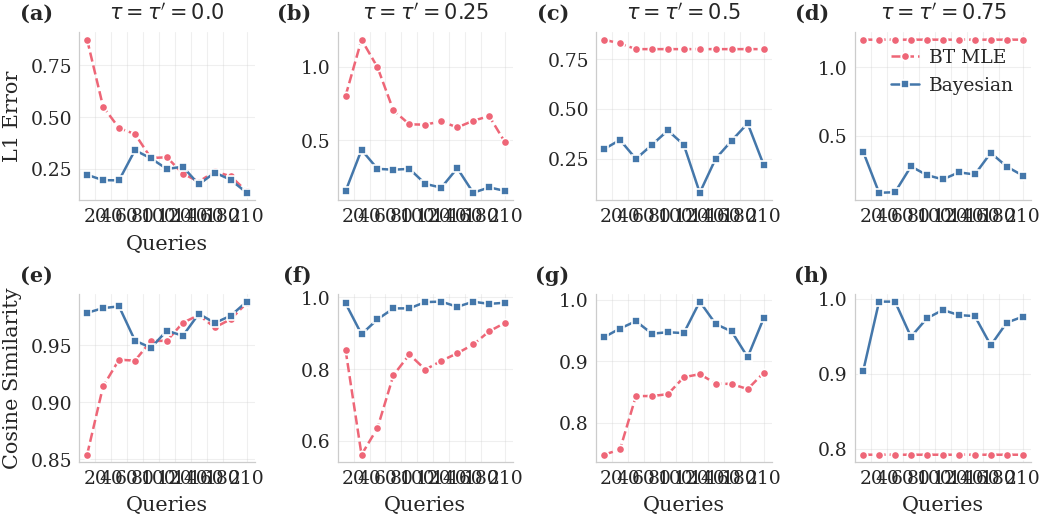


Plots saved to sample_size_experiment.pdf and .png


In [56]:
# ============================================================================
# PLOT: Sample Size vs Performance (Publication Quality)
# ============================================================================

from style import (paper_style, DOUBLE_COLUMN, plot_comparison, 
                   COLOR_A, COLOR_B, add_subplot_labels, savefig)

with paper_style(width=DOUBLE_COLUMN, aspect=0.5, font_size=10):
    fig, axes = plt.subplots(2, 4, figsize=(DOUBLE_COLUMN, DOUBLE_COLUMN * 0.5))
    
    for i, tau_val in enumerate(TAU_VALUES):
        # L1 error plot (top row)
        ax1 = axes[0, i]
        plot_comparison(
            ax1, 
            results[tau_val]['sample_sizes'], 
            results[tau_val]['bt_l1'], 
            results[tau_val]['bayes_l1'],
            label_a='BT MLE', 
            label_b='Bayesian',
            color_a=COLOR_B,  # red for BT
            color_b=COLOR_A,  # blue for Bayesian
            marker_a='o', 
            marker_b='s',
            linestyle_a='--',
            linestyle_b='-',
            markersize=4,
        )
        
        ax1.set_xlabel('Queries' if i == 0 else '')
        ax1.set_ylabel('L1 Error' if i == 0 else '')
        ax1.set_title(f"$\\tau = \\tau' = {tau_val}$")
        if i == 3:
            ax1.legend(loc='upper right')
        ax1.set_xticks([20, 40, 60, 80, 100, 120, 140, 160, 180,210])
        
        # Cosine similarity plot (bottom row)
        ax2 = axes[1, i]
        plot_comparison(
            ax2, 
            results[tau_val]['sample_sizes'], 
            results[tau_val]['bt_cos'], 
            results[tau_val]['bayes_cos'],
            label_a='BT MLE', 
            label_b='Bayesian',
            color_a=COLOR_B,
            color_b=COLOR_A,
            marker_a='o', 
            marker_b='s',
            linestyle_a='--',
            linestyle_b='-',
            markersize=4,
        )
        
        ax2.set_xlabel('Queries')
        ax2.set_ylabel('Cosine Similarity' if i == 0 else '')
        ax2.set_xticks([20, 40, 60, 80, 100, 120, 140, 160, 180,210])
    
    # Add subplot labels
    add_subplot_labels(axes, fontsize=10)
    
    plt.tight_layout()
    savefig(fig, 'sample_size_experiment', formats=['pdf', 'png'])
    plt.show()

print("\nPlots saved to sample_size_experiment.pdf and .png")


In [ ]:
# ============================================================================
# EXPERIMENT: Does BT Converge with Enough Decisive Samples?
# ============================================================================
#
# Run active learning until BT gets 500 usable (left/right) queries.
# Track BT and Bayesian cosine similarity to oracle over time.
# 
# Question: Even with enough samples, does BT converge to the true oracle?
# Or does missing indifferent/incomparable information hurt it?
# ============================================================================

import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

# Fixed parameters
ORACLE_WEIGHTS = np.array([0.1, 0.4, 0.15, 0.15, 0.2])
SCALE_DELTA = 0.3
SCALE_R = 0.3
LAMBDA_X = 1.0

# Test different tau regimes
TAU_VALUES_TEST = [0.3, 0.5, 0.6]

# Target number of decisive (left/right) queries for BT
TARGET_DECISIVE = 200

print("=" * 70)
print("EXPERIMENT: BT Convergence with Enough Decisive Samples")
print("=" * 70)
print(f"Oracle weights: {ORACLE_WEIGHTS}")
print(f"Target decisive queries: {TARGET_DECISIVE}")
print(f"Noise: scale_Δ={SCALE_DELTA}, scale_r={SCALE_R}")
print()

convergence_results = {}

for tau_val in TAU_VALUES_TEST:
    print(f"\n{'='*70}")
    print(f"tau = tau' = {tau_val}")
    print("=" * 70)
    
    noise_fn = create_noise_fn('logistic', SCALE_DELTA, SCALE_R)
    
    transcript = []
    posterior_samples = np.random.dirichlet(np.ones(5), size=500)
    
    # Track metrics at checkpoints
    checkpoints = []  # (total_queries, decisive_queries, bt_cos, bayes_cos)
    
    decisive_count = 0
    total_queries = 0
    
    while decisive_count < TARGET_DECISIVE:
        # Generate candidate queries
        candidates = generate_candidate_queries_normalized(50)
        
        # Select query using BALD
        best_query, best_bald = None, -np.inf
        for query in candidates:
            score = bald_score(
                query, posterior_samples[:100],
                'logistic', SCALE_DELTA, SCALE_R,
                tau_val, tau_val, LAMBDA_X,
                max_samples=50, V=None, n_mc_samples=30
            )
            if score > best_bald:
                best_bald, best_query = score, query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Oracle response
        response = predict_response_noisy(
            best_query, ORACLE_WEIGHTS, noise_fn,
            tau_val, LAMBDA_X, tau_val, V=None
        )
        transcript.append((best_query, response))
        total_queries += 1
        
        if response in ('left', 'right'):
            decisive_count += 1
        
        # Update posterior every 20 queries
        if total_queries % 20 == 0:
            try:
                posterior_samples, _ = sample_posterior_hit_and_run(
                    transcript, 'logistic', SCALE_DELTA, SCALE_R,
                    tau_val, tau_val, LAMBDA_X,
                    n_samples=500, burn_in=300, n_mc_samples=30,
                    verbose=False, V=None
                )
            except:
                pass
        
        # Record checkpoint every 25 decisive queries
        if decisive_count > 0 and decisive_count % 25 == 0 and (len(checkpoints) == 0 or checkpoints[-1][1] != decisive_count):
            # BT estimate
            bt_weights = bt_mle(
                transcript, dim=5, lambda_x=LAMBDA_X, scale=SCALE_DELTA,
                l2_theta=0.0, forced_choice=False, seed=42, n_restarts=5
            )
            
            # Bayesian estimate
            try:
                bayes_samples, _ = sample_posterior_hit_and_run(
                    transcript, 'logistic', SCALE_DELTA, SCALE_R,
                    tau_val, tau_val, LAMBDA_X,
                    n_samples=500, burn_in=300, n_mc_samples=30,
                    verbose=False, V=None
                )
                bayes_weights = bayes_samples.mean(axis=0)
            except:
                bayes_weights = np.ones(5) / 5
            
            # Cosine similarities
            bt_cos = np.dot(bt_weights, ORACLE_WEIGHTS) / (
                np.linalg.norm(bt_weights) * np.linalg.norm(ORACLE_WEIGHTS) + 1e-10)
            bayes_cos = np.dot(bayes_weights, ORACLE_WEIGHTS) / (
                np.linalg.norm(bayes_weights) * np.linalg.norm(ORACLE_WEIGHTS) + 1e-10)
            
            checkpoints.append((total_queries, decisive_count, bt_cos, bayes_cos))
            
            if decisive_count % 100 == 0:
                print(f"  Decisive: {decisive_count}, Total: {total_queries}, "
                      f"BT cos: {bt_cos:.4f}, Bayes cos: {bayes_cos:.4f}")
    
    # Final counts
    resp_counts = Counter(r for _, r in transcript)
    print(f"\nFinal response distribution: {dict(resp_counts)}")
    print(f"Total queries needed for {TARGET_DECISIVE} decisive: {total_queries}")
    print(f"Fraction decisive: {decisive_count/total_queries:.1%}")
    
    convergence_results[tau_val] = {
        'checkpoints': checkpoints,
        'total_queries': total_queries,
        'response_counts': dict(resp_counts),
    }

print("\n" + "=" * 70)
print("Experiment complete!")
print("=" * 70)


EXPERIMENT: BT Convergence with Enough Decisive Samples
Oracle weights: [0.1  0.4  0.15 0.15 0.2 ]
Target decisive queries: 200
Noise: scale_Δ=0.3, scale_r=0.3


tau = tau' = 0.3
  Decisive: 100, Total: 260, BT cos: 0.8368, Bayes cos: 0.9320


In [ ]:
# ============================================================================
# PLOT: BT vs Bayesian Convergence
# ============================================================================

from style import paper_style, DOUBLE_COLUMN, COLOR_A, COLOR_B, add_subplot_labels, savefig

with paper_style(width=DOUBLE_COLUMN, aspect=0.4, font_size=10):
    fig, axes = plt.subplots(1, len(TAU_VALUES_TEST), figsize=(DOUBLE_COLUMN, DOUBLE_COLUMN * 0.35))
    
    for i, tau_val in enumerate(TAU_VALUES_TEST):
        ax = axes[i]
        checkpoints = convergence_results[tau_val]['checkpoints']
        
        decisive = [c[1] for c in checkpoints]
        bt_cos = [c[2] for c in checkpoints]
        bayes_cos = [c[3] for c in checkpoints]
        
        ax.plot(decisive, bt_cos, color=COLOR_B, linestyle='--', marker='o', 
                markersize=4, label='BT MLE', linewidth=1.5)
        ax.plot(decisive, bayes_cos, color=COLOR_A, linestyle='-', marker='s', 
                markersize=4, label='Bayesian', linewidth=1.5)
        
        ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        
        ax.set_xlabel('Decisive Queries (left/right)')
        if i == 0:
            ax.set_ylabel('Cosine Similarity')
        ax.set_title(f"$\\tau = \\tau' = {tau_val}$")
        ax.set_ylim(0.5, 1.05)
        ax.legend(loc='lower right')
        
        # Add annotation for fraction decisive
        frac = convergence_results[tau_val]['response_counts'].get('left', 0) + \
               convergence_results[tau_val]['response_counts'].get('right', 0)
        total = convergence_results[tau_val]['total_queries']
        ax.text(0.95, 0.05, f'{frac/total:.0%} decisive', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color='gray')
    
    add_subplot_labels(axes, fontsize=11)
    plt.tight_layout()
    savefig(fig, 'bt_convergence_experiment', formats=['pdf', 'png'])
    plt.show()

# Summary table
print("\n" + "=" * 70)
print("SUMMARY: Final Cosine Similarities")
print("=" * 70)
print(f"{'tau':<8} {'BT Final':<12} {'Bayes Final':<12} {'Gap':<10} {'% Decisive':<12}")
print("-" * 54)
for tau_val in TAU_VALUES_TEST:
    cp = convergence_results[tau_val]['checkpoints'][-1]
    bt_final, bayes_final = cp[2], cp[3]
    total = convergence_results[tau_val]['total_queries']
    print(f"{tau_val:<8} {bt_final:<12.4f} {bayes_final:<12.4f} {bayes_final-bt_final:<10.4f} {TARGET_DECISIVE/total:<12.1%}")
